# COM6003 CW1 — Buckinghamshire EPC Analysis

**Author:** Harry Lloyd (22224922)
**Module:** COM6003 Data Science
**Dataset:** Domestic Energy Performance Certificates, Buckinghamshire (`E06000060`)
**Source:** [EPC Open Data](https://epc.opendatacommunities.org/) — Ministry of Housing, Communities and Local Government

This notebook performs the full analysis pipeline:

1. Data acquisition & understanding
2. Data wrangling (cleaning, deduplication, outlier handling)
3. Feature engineering
4. Descriptive analytics
5. Diagnostic analytics
6. Predictive modelling
7. Feature importance and recommendations

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', context='notebook')

DATA_RAW = '../data/raw/certificates.csv'
DATA_CLEAN = '../data/processed/bucks_epc_clean.csv'
FIG_DIR = '../figures/'

RANDOM_STATE = 42

## 1. Data Acquisition & Understanding

The dataset was downloaded from the EPC Open Data portal on 22 May 2026,
filtered to the Buckinghamshire local authority (`E06000060`). The portal
is the official government source for all Energy Performance Certificates
issued under the Energy Performance of Buildings (England and Wales)
Regulations 2012.

**Collection methodology:** Each EPC is produced by an accredited Domestic
Energy Assessor (DEA) using the Reduced Standard Assessment Procedure
(RdSAP), a simplified version of SAP (BRE, 2014). The assessor inspects
the property and records standardised observations about the fabric,
heating system, and lighting, which feed into a deterministic calculation
of the SAP score (0–100) and a corresponding letter band (A–G).

**Important biases and limitations:**

- **Selection bias:** EPCs are only required at point of sale, let, or
  major refurbishment. Properties that rarely change hands are
  systematically under-represented.
- **Assessor variability:** Independent studies (Crawley et al., 2019)
  have shown meaningful between-assessor variation for the same property.
- **Model vs measured:** RdSAP estimates *theoretical* energy demand from
  a standard occupancy assumption, not actual measured consumption.
  Real bills can diverge substantially.
- **Default assumptions:** Where data is missing during inspection, RdSAP
  uses construction-age-band defaults — which can mask true variation.

We acknowledge these limitations explicitly in the report's Conclusion.

In [2]:
df = pd.read_csv(DATA_RAW, low_memory=False)
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Memory: {df.memory_usage(deep=True).sum() / 1e6:.0f} MB')

Shape: 204,347 rows × 93 columns


Memory: 770 MB


In [3]:
df.head(3)

,certificate_number,address1,address2,address3,address,postcode,inspection_date,uprn,environment_impact_potential,energy_consumption_current,energy_consumption_potential,environment_impact_current,co2_emissions_current,co2_emiss_curr_per_floor_area,co2_emissions_potential,total_floor_area,lodgement_date,report_type,posttown,lodgement_datetime,current_energy_efficiency,current_energy_rating,potential_energy_efficiency,potential_energy_rating,extension_count,number_open_fireplaces,number_heated_rooms,number_habitable_rooms,low_energy_lighting,low_energy_fixed_lighting_outlets_count,solar_water_heating_flag,mechanical_ventilation,tenure,property_type,transaction_type,construction_age_band,built_form,energy_tariff,glazed_type,glazed_area,heat_loss_corridor,main_fuel,unheated_corridor_length,floor_level,flat_top_storey,flat_storey_count,mains_gas_flag,photo_supply,wind_turbine_count,lighting_cost_current,lighting_cost_potential,heating_cost_current,heating_cost_potential,hot_water_cost_current,hot_water_cost_potential,multi_glaze_proportion,hotwater_description,hot_water_energy_eff,hot_water_env_eff,floor_description,floor_energy_eff,floor_env_eff,roof_description,roof_energy_eff,roof_env_eff,walls_description,walls_energy_eff,walls_env_eff,windows_description,windows_energy_eff,windows_env_eff,secondheat_description,sheating_energy_eff,sheating_env_eff,mainheat_description,mainheat_energy_eff,mainheat_env_eff,mainheatcont_description,mainheatc_energy_eff,mainheatc_env_eff,lighting_description,lighting_energy_eff,lighting_env_eff,fixed_lighting_outlets_count,floor_height,main_heating_controls,local_authority,local_authority_label,constituency_label,constituency,country,region,uprn_source
0,2315-3061-1204-7816-8204,12 Westmorland Avenue,NaN,NaN,12 Westmorland Avenue,HP21 7HW,2026-04-29,7.660190e+08,80,171,107,69,3.2,30.0,2.1,106,2026-04-29,2,AYLESBURY,2026-04-29 14:31:08,69,C,80,C,0.0,NaN,6.0,6.0,100.0,22.0,N,natural,owner-occupied,House,Marketed sale,England and Wales: 1950-1966,Semi-Detached,Single,NaN,NaN,NaN,mains gas (not community),NaN,NaN,N,2.0,Y,0.0,0.0,62,62,1032,697,374,354,100.0,From main system,Good,Good,"Solid, no insulation (assumed)",NaN,NaN,"Pitched, 175 mm loft insulation",Good,Good,"Cavity wall, as built, no insulation (assumed)",Poor,Poor,Fully double glazed,Average,Average,NaN,NaN,NaN,"Boiler and radiators, mains gas",Good,Good,"Programmer, room thermostat and TRVs",Good,Good,Good lighting efficiency,Good,Good,22.0,2.30,"Programmer, room thermostat and TRVs",E06000060,Buckinghamshire,Aylesbury,E14001071,England,E12000008,Energy Assessor
1,2347-3061-3204-2346-8204,33 The Warren,NaN,NaN,33 The Warren,HP5 2RX,2026-04-24,1.000805e+11,69,189,159,65,4.9,35.0,4.2,141,2026-04-29,2,CHESHAM,2026-04-29 19:25:17,69,C,75,C,2.0,NaN,7.0,7.0,100.0,25.0,N,natural,owner-occupied,House,Marketed sale,England and Wales: 1967-1975,Detached,Single,NaN,NaN,NaN,mains gas (not community),NaN,NaN,N,2.0,Y,0.0,0.0,77,77,1571,1378,269,270,100.0,From main system,Good,Good,"Solid, no insulation (assumed)",NaN,NaN,"Pitched, 100 mm loft insulation",Average,Average,"Cavity wall, filled cavity",Good,Good,Fully double glazed,Average,Average,NaN,NaN,NaN,"Boiler and radiators, mains gas",Good,Good,"Programmer, room thermostat and TRVs",Good,Good,Good lighting efficiency,Good,Good,25.0,2.43,"Programmer, room thermostat and TRVs",E06000060,Buckinghamshire,Mid Buckinghamshire,E14001360,England,E12000008,Energy Assessor
2,0100-8653-0922-5624-3463,The Stable,Little Kings Ash Farm,Chesham Lane,"The Stable, Little Kings Ash Farm, Chesham Lane",HP16 9NP,2026-04-25,1.001378e+10,50,415,392,49,3.0,87.0,2.9,35,2026-04-29,2,KINGS ASH,2026-04-29 19:31:10,59,D,64,D,0.0,NaN,2.0,2.0,100.0,12.0,N,natural,owner-occupied,Bungalow,Marketed sale,England and Wales: 2007-2011,End-Terrace,Single,NaN,NaN,NaN,LPG (community),NaN,NaN,N,1.0,N,0.0,0.0,24,24,613,613,216,216,100.0,Community scheme,Average,Poor,"Solid, insulated (assumed)",NaN,NaN,"Pitched, insulated",Good,Good,"Cavi

In [4]:
# Inspection date range — how recent and how broad is the data?
df['inspection_date'] = pd.to_datetime(df['inspection_date'], errors='coerce')
print(f'Earliest inspection: {df["inspection_date"].min().date()}')
print(f'Latest inspection:   {df["inspection_date"].max().date()}')

Earliest inspection: 2011-02-11
Latest inspection:   2026-04-30


In [5]:
# Target variable distribution
target_dist = df['current_energy_rating'].value_counts().sort_index()
print('Current energy rating distribution:')
print(target_dist)
print(f'\nTotal: {target_dist.sum():,}')

Current energy rating distribution:
current_energy_rating
A     1019
B    29442
C    71395
D    70458
E    24744
F     5925
G     1364
Name: count, dtype: int64

Total: 204,347


## 2. Data Wrangling

The raw data has several quality issues that need to be addressed before
analysis:

1. **Duplicates** — the same property (UPRN) may have multiple EPCs over
   time as it gets re-inspected. We keep only the most recent certificate
   per property.
2. **Empty columns** — some columns are 100% missing (e.g.
   `sheating_energy_eff`) and provide no information.
3. **Categorical inconsistencies** — `tenure`, `main_fuel`, and
   `construction_age_band` have multiple labels referring to the same
   category due to historical schema changes. These need to be harmonised.
4. **Outliers** — some numeric columns contain implausible values
   (`current_energy_efficiency` > 100, `total_floor_area` > 1,000 m²).
5. **Missing values** — handled column by column based on the nature of
   the variable and its missingness pattern.

### 2.1 Deduplicate — keep latest certificate per property

In [6]:
# Some UPRNs have many certificates. Keep only the most recent for each property.
print(f'Before dedup:  {len(df):,} rows')
print(f'Unique UPRNs:  {df["uprn"].nunique():,}')
print(f'Missing UPRNs: {df["uprn"].isna().sum():,}')

# For rows without UPRN, fall back to certificate_number (always unique)
df['_uprn_key'] = df['uprn'].fillna(df['certificate_number'])

df = (df
      .sort_values('inspection_date')
      .drop_duplicates(subset='_uprn_key', keep='last')
      .drop(columns='_uprn_key')
      .reset_index(drop=True))

print(f'After dedup:   {len(df):,} rows')

Before dedup:  204,347 rows
Unique UPRNs:  156,021
Missing UPRNs: 1,296


After dedup:   157,317 rows


### 2.2 Drop fully-empty and irrelevant columns

In [7]:
# Columns that are 100% missing carry no information
all_null = df.columns[df.isna().all()].tolist()
print(f'Fully-null columns to drop: {all_null}')

# Free-text address fields and IDs are not predictive
admin_cols = ['certificate_number', 'address1', 'address2', 'address3',
              'address', 'uprn', 'lodgement_date', 'lodgement_datetime',
              'report_type', 'uprn_source', 'country', 'region',
              'local_authority', 'local_authority_label',
              'constituency', 'constituency_label']

# Columns with >85% missing rarely add predictive signal and risk overfitting
high_missing = df.columns[df.isna().mean() > 0.85].tolist()
print(f'High-missing (>85%) columns to drop: {high_missing}')

to_drop = list(set(all_null + admin_cols + high_missing))
df = df.drop(columns=[c for c in to_drop if c in df.columns])
print(f'\nColumns remaining: {df.shape[1]}')

Fully-null columns to drop: ['sheating_energy_eff', 'sheating_env_eff']


High-missing (>85%) columns to drop: ['address3', 'unheated_corridor_length', 'floor_energy_eff', 'floor_env_eff', 'sheating_energy_eff', 'sheating_env_eff']



Columns remaining: 72


### 2.3 Harmonise categorical inconsistencies

In [8]:
# Tenure has casing inconsistencies — 'owner-occupied' and 'Owner-occupied' are the same
df['tenure'] = df['tenure'].str.lower().str.strip()
print('Tenure after lowercasing:')
print(df['tenure'].value_counts(dropna=False))

Tenure after lowercasing:
tenure
owner-occupied      87634
rented (social)     23422
unknown             22709
rented (private)    18742
NaN                  4810
Name: count, dtype: int64


In [9]:
# main_fuel has multiple labels referring to the same fuel + some \n artefacts
df['main_fuel'] = df['main_fuel'].str.replace('\n', '', regex=False).str.strip().str.lower()

def simplify_fuel(s):
    if pd.isna(s):
        return np.nan
    s = s.lower()
    if 'mains gas' in s or s.startswith('gas: mains'):
        return 'mains gas'
    if 'lpg' in s:
        return 'lpg'
    if 'electricity' in s:
        return 'electricity'
    if 'oil' in s:
        return 'oil'
    if 'wood' in s or 'biomass' in s or 'logs' in s or 'pellets' in s or 'chips' in s:
        return 'biomass'
    if 'coal' in s or 'anthracite' in s or 'smokeless' in s:
        return 'solid fuel'
    if 'community' in s:
        return 'community heating'
    if 'dual fuel' in s:
        return 'dual fuel'
    return 'other'

df['main_fuel_grouped'] = df['main_fuel'].apply(simplify_fuel)
print(df['main_fuel_grouped'].value_counts(dropna=False))

main_fuel_grouped
mains gas            126840
electricity           19678
oil                    7165
lpg                    1854
NaN                    1181
biomass                 291
community heating       196
solid fuel               83
other                    29
Name: count, dtype: int64


In [10]:
# construction_age_band has two formats: 'England and Wales: 1950-1966' vs just '2019'
def parse_age_band(s):
    if pd.isna(s):
        return np.nan
    s = str(s).replace('England and Wales:', '').strip()
    if 'before 1900' in s.lower():
        return 1899
    if 'onwards' in s.lower():
        # e.g. '2012 onwards' — take the start year
        return int(s.split()[0])
    if '-' in s:
        # range like '1950-1966' — take midpoint
        try:
            a, b = s.split('-')
            return (int(a.strip()) + int(b.strip())) / 2
        except ValueError:
            return np.nan
    # single year like '2019'
    try:
        return int(s)
    except ValueError:
        return np.nan

df['construction_year'] = df['construction_age_band'].apply(parse_age_band)
print(df['construction_year'].describe())

# Also clip implausible parsed years
df.loc[df['construction_year'] < 1700, 'construction_year'] = np.nan
df.loc[df['construction_year'] > 2030, 'construction_year'] = np.nan
print(f'\nYears outside [1700, 2030] set to NaN. Remaining missing: {df["construction_year"].isna().sum()}')

# Build a clean 7-band categorical that replaces the raw construction_age_band
age_bins = [-np.inf, 1900, 1930, 1950, 1970, 1990, 2010, np.inf]
age_labels = ['<1900', '1900-1929', '1930-1949', '1950-1969',
              '1970-1989', '1990-2009', '2010+']
df['age_band'] = pd.cut(df['construction_year'], bins=age_bins, labels=age_labels)
print(f'Clean age_band distribution:')
print(df['age_band'].value_counts(dropna=False).sort_index())

count    153884.000000
mean       1973.871182
std          34.450899
min        1780.000000
25%        1958.000000
50%        1971.000000
75%        2004.500000
max        3013.000000
Name: construction_year, dtype: float64

Years outside [1700, 2030] set to NaN. Remaining missing: 3434
Clean age_band distribution:
age_band
<1900         8302
1900-1929    10041
1930-1949    12018
1950-1969    28093
1970-1989    42711
1990-2009    22068
2010+        30650
NaN           3434
Name: count, dtype: int64


### 2.4 Outlier handling

In [11]:
# current_energy_efficiency should be 0-100 by definition (SAP scale)
print('Before:', df['current_energy_efficiency'].describe()[['min', 'max']].to_dict())
bad = ((df['current_energy_efficiency'] < 1) | (df['current_energy_efficiency'] > 100)).sum()
print(f'Implausible SAP scores: {bad}')
df = df[(df['current_energy_efficiency'] >= 1) & (df['current_energy_efficiency'] <= 100)].copy()
print('After: ', df['current_energy_efficiency'].describe()[['min', 'max']].to_dict())

Before: {'min': 1.0, 'max': 277.0}
Implausible SAP scores: 85


After:  {'min': 1.0, 'max': 100.0}


In [12]:
# total_floor_area — anything above the 99.5th percentile is implausible for a domestic dwelling
fa_cap = df['total_floor_area'].quantile(0.995)
print(f'99.5th percentile floor area: {fa_cap:.1f} m²')
print(f'Records above this: {(df["total_floor_area"] > fa_cap).sum()}')

# Cap rather than drop (preserve sample size, follow standard winsorisation)
df['total_floor_area'] = df['total_floor_area'].clip(upper=fa_cap)

# Also drop properties with implausibly small areas (<10 m²)
small = (df['total_floor_area'] < 10).sum()
print(f'Records with <10 m² floor area (dropped): {small}')
df = df[df['total_floor_area'] >= 10].copy()

99.5th percentile floor area: 481.8 m²
Records above this: 787
Records with <10 m² floor area (dropped): 24


### 2.5 Missing-value strategy

In [13]:
# Summary of remaining missingness
miss = df.isna().sum().sort_values(ascending=False)
miss_pct = (miss / len(df) * 100).round(1)
remaining_missing = pd.DataFrame({'n_missing': miss, 'pct_missing': miss_pct})
remaining_missing = remaining_missing[remaining_missing['n_missing'] > 0]
remaining_missing.head(25)

,n_missing,pct_missing
heat_loss_corridor,131380,83.6
floor_level,118291,75.2
secondheat_description,103197,65.6
glazed_type,56094,35.7
glazed_area,56094,35.7
photo_supply,46998,29.9
mains_gas_flag,45396,28.9
mechanical_ventilation,27840,17.7
extension_count,27839,17.7
number_habitable_rooms,27839,17.7


In [14]:
# Numeric: impute with median (robust to outliers)
# Categorical: impute with 'unknown' (preserve the missingness as a category)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Don't impute the target!
TARGETS = ['current_energy_efficiency', 'current_energy_rating']
numeric_cols = [c for c in numeric_cols if c not in TARGETS]

for col in numeric_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna('unknown')

print(f'Remaining missing: {df.isna().sum().sum()}')
print(f'Final shape: {df.shape}')

Remaining missing: 3432
Final shape: (157208, 75)


### 2.6 Save cleaned dataset

In [15]:
import os
os.makedirs('../data/processed', exist_ok=True)

# Save uncompressed for fast loading in subsequent cells
df.to_csv(DATA_CLEAN, index=False)

# Also save a gzipped copy for the repo (the uncompressed file is >100MB,
# which exceeds GitHub's per-file limit)
df.to_csv(DATA_CLEAN + '.gz', index=False, compression='gzip')

print(f'Saved: {DATA_CLEAN}  ({os.path.getsize(DATA_CLEAN) / 1e6:.1f} MB)')
print(f'Saved: {DATA_CLEAN}.gz  ({os.path.getsize(DATA_CLEAN + ".gz") / 1e6:.1f} MB)')
print(f'Shape: {df.shape}')

Saved: ../data/processed/bucks_epc_clean.csv  (117.9 MB)
Saved: ../data/processed/bucks_epc_clean.csv.gz  (11.6 MB)
Shape: (157208, 75)


## 3. Feature Engineering

The cleaned dataset gives us 73 columns of raw observations. To extract
predictive signal, we engineer a smaller set of more informative features:

1. **Ordinal encoding** of the seven `*_energy_eff` columns
   (`Very Poor` → `Very Good` as 1–5). These are inherently ordered.
2. **Composite scores** — a *fabric efficiency* score (envelope: walls,
   roof, windows, floor) and a *systems efficiency* score (heating,
   hot water, lighting). Composite scores capture related-feature
   signal that may be noisy at the individual level.
3. **Building age** — derived from the parsed `construction_year`.
4. **Energy intensity** — `energy_consumption_current / total_floor_area`
   (kWh/m²/yr). This normalises for property size and is the metric
   used in most academic EPC literature (Hardy & Glew, 2019).
5. **Log-transformed floor area** — `total_floor_area` is right-skewed;
   the log transform improves linearity for regression models.
6. **Heating cost intensity** — `heating_cost_current / total_floor_area`.
7. **Simplified categorical groupings** for `built_form` (rare categories
   merged) and a derived `postcode_district` for geographic signal.

### 3.1 Load the cleaned data

In [16]:
# Reload the cleaned dataset (so this section can be re-run independently)
df = pd.read_csv(DATA_CLEAN, low_memory=False)
df['inspection_date'] = pd.to_datetime(df['inspection_date'], errors='coerce')
print(f'Shape: {df.shape}')

Shape: (157208, 75)


### 3.2 Ordinal encoding of efficiency ratings

In [17]:
# All *_energy_eff columns use the same 5-point ordinal scale
EFF_MAP = {
    'Very Poor': 1,
    'Poor': 2,
    'Average': 3,
    'Good': 4,
    'Very Good': 5,
    'unknown': np.nan,
    'N/A': np.nan,
}

eff_cols = [c for c in df.columns if c.endswith('_energy_eff')]
print(f'Ordinal-encoding {len(eff_cols)} columns: {eff_cols}')

for c in eff_cols:
    df[c + '_ord'] = df[c].map(EFF_MAP)

# Quick check
df[[c + '_ord' for c in eff_cols]].describe()

Ordinal-encoding 7 columns: ['hot_water_energy_eff', 'roof_energy_eff', 'walls_energy_eff', 'windows_energy_eff', 'mainheat_energy_eff', 'mainheatc_energy_eff', 'lighting_energy_eff']


,hot_water_energy_eff_ord,roof_energy_eff_ord,walls_energy_eff_ord,windows_energy_eff_ord,mainheat_energy_eff_ord,mainheatc_energy_eff_ord,lighting_energy_eff_ord
count,157207.000000,136409.000000,157206.000000,157206.000000,157207.000000,157206.000000,157207.000000
mean,3.588549,3.581157,3.347442,3.524611,3.709994,3.815446,4.218190
std,0.874616,1.168642,1.265712,0.912620,0.774415,0.789383,1.229953
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,3.000000,3.000000,2.000000,3.000000,4.000000,3.000000,4.000000
50%,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,5.000000
75%,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


### 3.3 Composite fabric and systems scores

In [18]:
# Fabric (passive envelope) — what stops heat escaping
fabric_cols = ['walls_energy_eff_ord', 'roof_energy_eff_ord',
               'windows_energy_eff_ord']
df['fabric_score'] = df[fabric_cols].mean(axis=1)

# Systems (active) — heating, hot water, lighting
system_cols = ['mainheat_energy_eff_ord', 'hot_water_energy_eff_ord',
               'lighting_energy_eff_ord']
df['systems_score'] = df[system_cols].mean(axis=1)

print('Fabric score:')
print(df['fabric_score'].describe())
print()
print('Systems score:')
print(df['systems_score'].describe())

Fabric score:
count    157207.000000
mean          3.491607
std           0.905590
min           1.000000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: fabric_score, dtype: float64

Systems score:
count    157207.000000
mean          3.838911
std           0.664025
min           1.000000
25%           3.333333
50%           4.000000
75%           4.333333
max           5.000000
Name: systems_score, dtype: float64


### 3.4 Building age

In [19]:
# Current year minus parsed construction year. The dataset spans 2008-2026
# inspections so we use the inspection year as the reference, not 'today'.
df['inspection_year'] = df['inspection_date'].dt.year
df['building_age_years'] = df['inspection_year'] - df['construction_year']

# A handful of negative ages (inspection date before recorded construction year)
neg = (df['building_age_years'] < 0).sum()
print(f'Negative ages (data error, clipped to 0): {neg}')
df['building_age_years'] = df['building_age_years'].clip(lower=0, upper=200)

print(df['building_age_years'].describe())

Negative ages (data error, clipped to 0): 509
count    157208.000000
mean         45.882630
std          34.087187
min           0.000000
25%          16.000000
50%          45.000000
75%          64.000000
max         200.000000
Name: building_age_years, dtype: float64


### 3.5 Energy and cost intensity (per m²)

In [20]:
# Energy consumption per square metre — the standard EPC intensity metric
df['energy_per_m2'] = df['energy_consumption_current'] / df['total_floor_area']

# Heating cost per square metre (annual £/m²)
df['heating_cost_per_m2'] = df['heating_cost_current'] / df['total_floor_area']

# Log-transformed floor area (right-skewed in raw form)
df['log_floor_area'] = np.log1p(df['total_floor_area'])

# Defensive: replace any infinities from divide-by-zero with NaN
for c in ['energy_per_m2', 'heating_cost_per_m2']:
    df[c] = df[c].replace([np.inf, -np.inf], np.nan)
    df[c] = df[c].fillna(df[c].median())

print(df[['energy_per_m2', 'heating_cost_per_m2', 'log_floor_area']].describe())

       energy_per_m2  heating_cost_per_m2  log_floor_area
count  157208.000000        157208.000000   157208.000000
mean        2.923783             7.918362        4.506368
std         3.202717             4.853977        0.517522
min        -2.066667            -0.012987        2.397895
25%         1.263158             4.914286        4.174387
50%         2.241379             7.000000        4.454347
75%         3.543895             9.753127        4.804021
max       368.681818            97.961538        6.179696


### 3.6 Categorical simplification and geographic features

In [21]:
# built_form has rare categories that won't help the model
form_counts = df['built_form'].value_counts()
print('built_form counts:')
print(form_counts)

# Keep the top categories; merge the rest into 'Other'
common_forms = form_counts[form_counts >= 1000].index
df['built_form_simple'] = df['built_form'].where(
    df['built_form'].isin(common_forms), 'Other'
)
print()
print('After simplification:')
print(df['built_form_simple'].value_counts())

built_form counts:
built_form
Detached                50580
Semi-Detached           50191
Mid-Terrace             28980
End-Terrace             20180
Enclosed End-Terrace     2499
Not Recorded             2404
unknown                  1335
Enclosed Mid-Terrace     1039
Name: count, dtype: int64

After simplification:
built_form_simple
Detached                50580
Semi-Detached           50191
Mid-Terrace             28980
End-Terrace             20180
Enclosed End-Terrace     2499
Not Recorded             2404
unknown                  1335
Enclosed Mid-Terrace     1039
Name: count, dtype: int64


In [22]:
# Postcode district — the part before the space (e.g. 'HP11' from 'HP11 2JZ')
df['postcode_district'] = df['postcode'].str.split().str[0]
print(f'Unique postcode districts: {df["postcode_district"].nunique()}')
print('Top 15:')
print(df['postcode_district'].value_counts().head(15))

Unique postcode districts: 46
Top 15:
postcode_district
HP13    13293
HP22    10715
MK18    10406
HP21     9580
HP19     7812
HP5      7044
HP18     6965
HP12     6194
HP11     5988
SL9      5847
SL7      5725
HP10     5388
HP9      5027
HP14     4983
HP20     4953
Name: count, dtype: int64


### 3.7 Final engineered feature set

In [23]:
# Summarise what we've added
engineered = ['fabric_score', 'systems_score', 'building_age_years',
              'energy_per_m2', 'heating_cost_per_m2', 'log_floor_area',
              'built_form_simple', 'postcode_district'] +              [c + '_ord' for c in eff_cols]

print(f'Engineered {len(engineered)} new features.')
print()
print('Sample correlations with current_energy_efficiency:')
numeric_engineered = [c for c in engineered
                      if df[c].dtype != 'object']
corrs = df[numeric_engineered + ['current_energy_efficiency']].corr()['current_energy_efficiency']
print(corrs.drop('current_energy_efficiency').sort_values(ascending=False))

Engineered 15 new features.

Sample correlations with current_energy_efficiency:


fabric_score                0.722956
walls_energy_eff_ord        0.660218
windows_energy_eff_ord      0.559555
roof_energy_eff_ord         0.540848
systems_score               0.521435
mainheatc_energy_eff_ord    0.482928
hot_water_energy_eff_ord    0.442596
lighting_energy_eff_ord     0.337038
mainheat_energy_eff_ord     0.306158
log_floor_area             -0.082831
energy_per_m2              -0.317948
building_age_years         -0.601681
heating_cost_per_m2        -0.707592
Name: current_energy_efficiency, dtype: float64


## 4. Descriptive Analytics

Now we explore the distribution of energy efficiency across the
Buckinghamshire housing stock. The goal is to characterise *what* the
data looks like before asking *why* it looks that way (Section 5)
and *what we can predict* from it (Section 6).

All figures generated in this section are saved to `../figures/` for
inclusion in the report.

In [24]:
import os
os.makedirs(FIG_DIR, exist_ok=True)

# Official EPC band colours (from the certificate itself)
EPC_COLOURS = {
    'A': '#008054',
    'B': '#19B459',
    'C': '#8DCE46',
    'D': '#FFD500',
    'E': '#FCAA65',
    'F': '#EF8023',
    'G': '#E9153B',
}

# Order for plots
RATING_ORDER = list('ABCDEFG')

### 4.1 Rating distribution

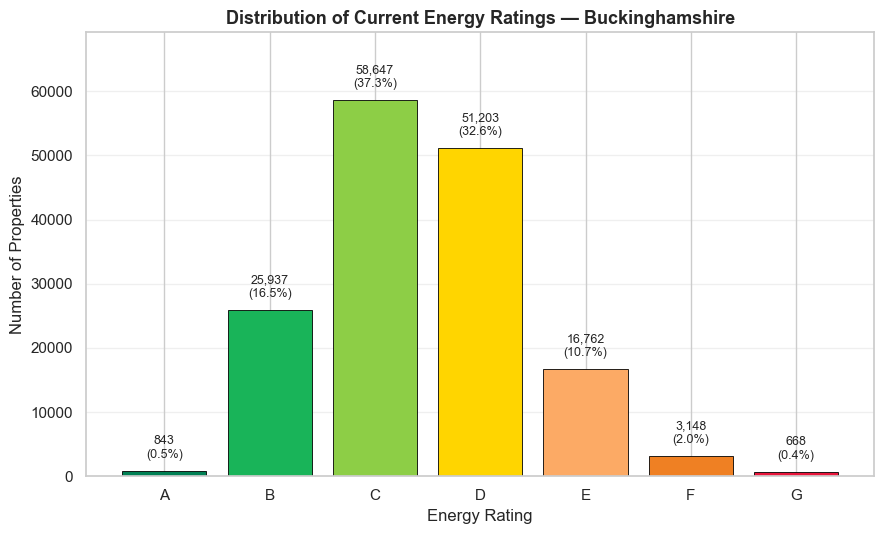

Mode: C (58,647 properties)
A+B share: 17.0%
F+G share: 2.4%


In [25]:
fig, ax = plt.subplots(figsize=(9, 5.5))
counts = df['current_energy_rating'].value_counts().reindex(RATING_ORDER)
bars = ax.bar(counts.index, counts.values,
              color=[EPC_COLOURS[r] for r in counts.index],
              edgecolor='black', linewidth=0.6)

# Add count labels
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1500,
            f'{val:,}\n({val/counts.sum()*100:.1f}%)',
            ha='center', va='bottom', fontsize=9)

ax.set_title('Distribution of Current Energy Ratings — Buckinghamshire',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Energy Rating')
ax.set_ylabel('Number of Properties')
ax.set_ylim(0, counts.max() * 1.18)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR + 'fig01_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mode: {counts.idxmax()} ({counts.max():,} properties)')
print(f'A+B share: {counts[["A","B"]].sum() / counts.sum() * 100:.1f}%')
print(f'F+G share: {counts[["F","G"]].sum() / counts.sum() * 100:.1f}%')

### 4.2 SAP score (numeric) distribution

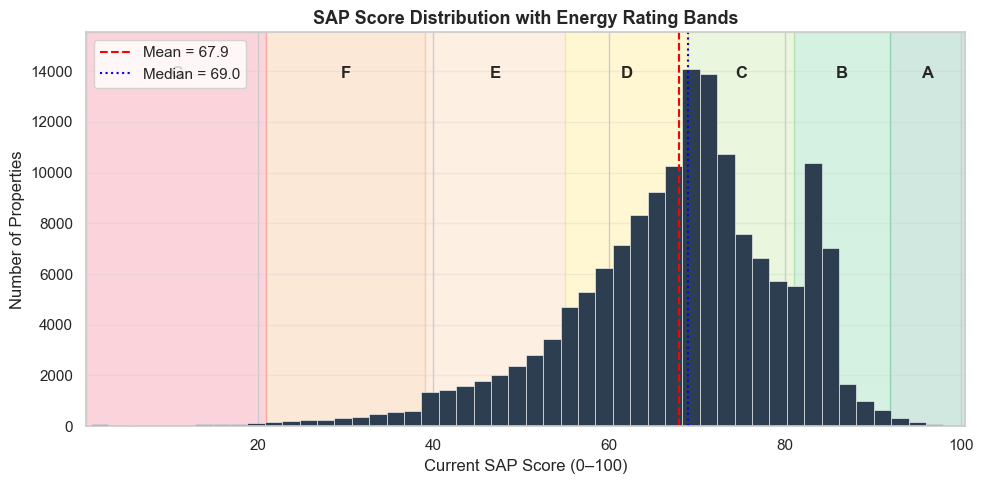

Mean SAP: 67.9  |  Median: 69.0
Standard deviation: 12.7


In [26]:
fig, ax = plt.subplots(figsize=(10, 5))

# Histogram first so we know the y-axis range
ax.hist(df['current_energy_efficiency'], bins=50,
        color='#2c3e50', edgecolor='white', linewidth=0.4)
ymax = ax.get_ylim()[1]

# Background band shading — gapless (use the inclusive edges from EPC bands)
band_edges = [(92, 100.5, 'A'), (81, 92, 'B'), (69, 81, 'C'),
              (55, 69, 'D'), (39, 55, 'E'), (21, 39, 'F'), (0.5, 21, 'G')]
for lo, hi, band in band_edges:
    ax.axvspan(lo, hi, alpha=0.18, color=EPC_COLOURS[band], zorder=0)
    # Label at top of chart
    ax.text((lo+hi)/2, ymax * 0.96, band,
            ha='center', va='top', fontsize=12, fontweight='bold')

# Mean and median lines on top
mean_sap = df['current_energy_efficiency'].mean()
median_sap = df['current_energy_efficiency'].median()
ax.axvline(mean_sap, color='red', linestyle='--', linewidth=1.5,
           label=f'Mean = {mean_sap:.1f}')
ax.axvline(median_sap, color='blue', linestyle=':', linewidth=1.5,
           label=f'Median = {median_sap:.1f}')

ax.set_title('SAP Score Distribution with Energy Rating Bands',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Current SAP Score (0–100)')
ax.set_ylabel('Number of Properties')
ax.set_xlim(0.5, 100.5)
ax.set_ylim(0, ymax * 1.05)
ax.legend(loc='upper left')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR + 'fig02_sap_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mean SAP: {mean_sap:.1f}  |  Median: {median_sap:.1f}')
print(f'Standard deviation: {df["current_energy_efficiency"].std():.1f}')

### 4.3 Efficiency by property type

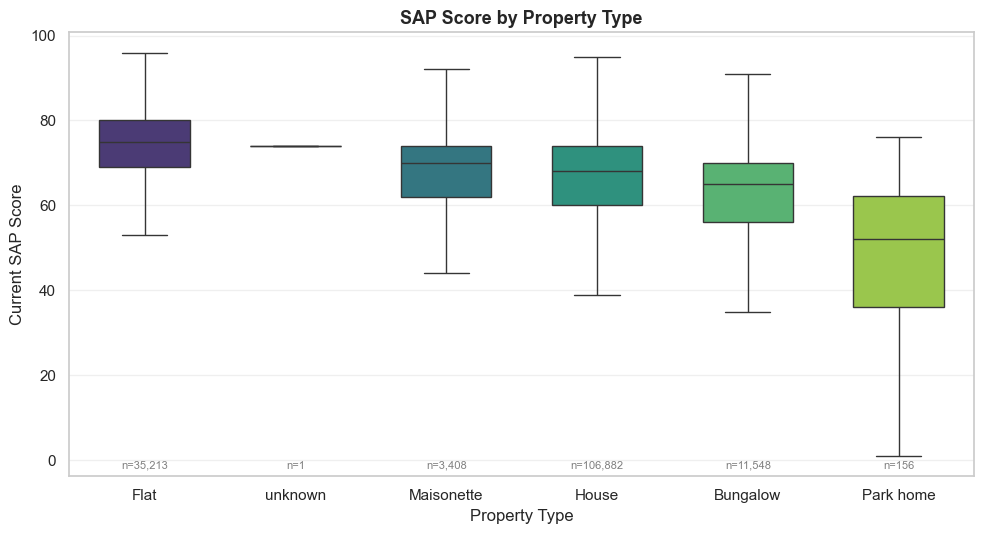

Median SAP by property type:
property_type
Flat          75.0
unknown       74.0
Maisonette    70.0
House         68.0
Bungalow      65.0
Park home     52.0
Name: current_energy_efficiency, dtype: float64


In [27]:
fig, ax = plt.subplots(figsize=(10, 5.5))

# Order property types by median efficiency
order = (df.groupby('property_type')['current_energy_efficiency']
           .median().sort_values(ascending=False).index)

sns.boxplot(data=df, x='property_type', y='current_energy_efficiency',
            order=order, ax=ax, palette='viridis',
            showfliers=False, width=0.6)

ax.set_title('SAP Score by Property Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Property Type')
ax.set_ylabel('Current SAP Score')
ax.grid(axis='y', alpha=0.3)

# Annotate sample sizes
for i, pt in enumerate(order):
    n = (df['property_type'] == pt).sum()
    ax.text(i, df['current_energy_efficiency'].min() - 3,
            f'n={n:,}', ha='center', fontsize=8, color='grey')

plt.tight_layout()
plt.savefig(FIG_DIR + 'fig03_efficiency_by_property_type.png', dpi=150, bbox_inches='tight')
plt.show()

# Print medians
print('Median SAP by property type:')
print(df.groupby('property_type')['current_energy_efficiency'].median().sort_values(ascending=False))

### 4.4 Efficiency by tenure

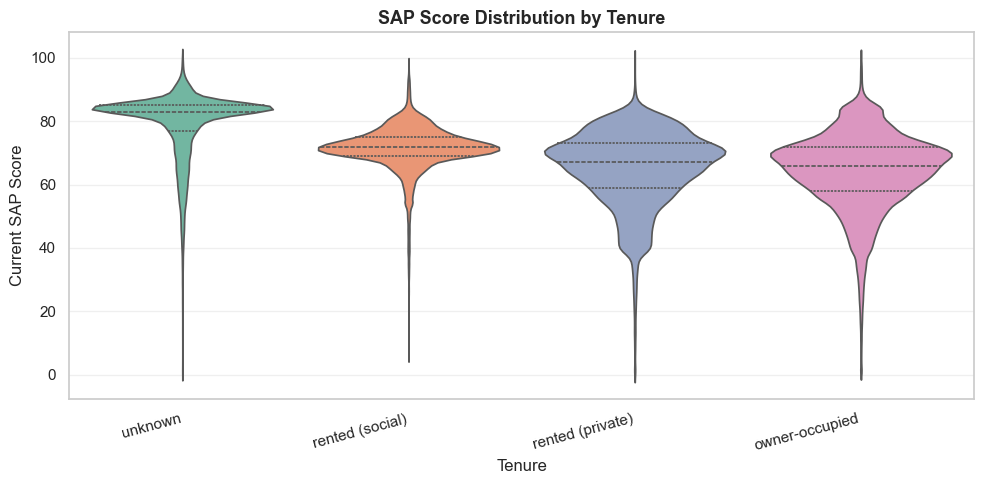

SAP by tenure (median, mean, count):
                  median  mean  count
tenure                               
owner-occupied      66.0  64.1  87591
rented (private)    67.0  64.9  18737
rented (social)     72.0  71.5  23403
unknown             83.0  79.2  27477


In [28]:
fig, ax = plt.subplots(figsize=(10, 5))

# Filter to tenures with >500 records to avoid noisy categories
tenure_counts = df['tenure'].value_counts()
major_tenures = tenure_counts[tenure_counts > 500].index
sub = df[df['tenure'].isin(major_tenures)]

order = (sub.groupby('tenure')['current_energy_efficiency']
            .median().sort_values(ascending=False).index)

sns.violinplot(data=sub, x='tenure', y='current_energy_efficiency',
               order=order, ax=ax, palette='Set2', inner='quartile')

ax.set_title('SAP Score Distribution by Tenure', fontsize=13, fontweight='bold')
ax.set_xlabel('Tenure')
ax.set_ylabel('Current SAP Score')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15, ha='right')

plt.tight_layout()
plt.savefig(FIG_DIR + 'fig04_efficiency_by_tenure.png', dpi=150, bbox_inches='tight')
plt.show()

print('SAP by tenure (median, mean, count):')
print(sub.groupby('tenure')['current_energy_efficiency'].agg(['median','mean','count']).round(1))

### 4.5 Efficiency vs construction age

           mean   std  count
age_band                    
1900-1929  57.3  12.0  10038
1930-1949  60.4  11.7  12014
1950-1969  63.7  10.7  28083
1970-1989  66.3   9.1  42708
1990-2009  72.6   7.6  22047
2010+      81.8   6.6  30587
<1900      53.6  15.6   8299


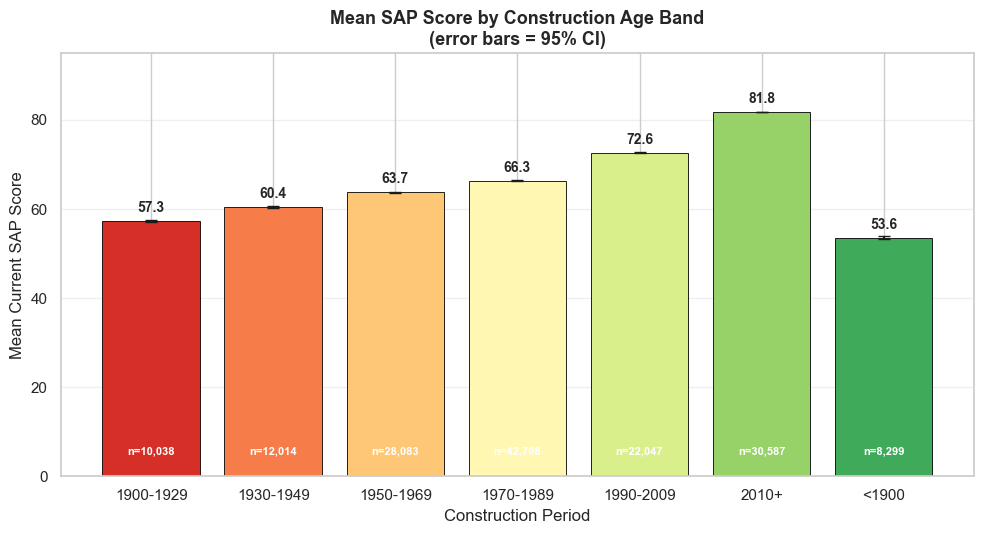

In [29]:
# age_band was created in the wrangling section (Section 2.3)

fig, ax = plt.subplots(figsize=(10, 5.5))

means = df.groupby('age_band', observed=True)['current_energy_efficiency'].agg(['mean','std','count'])
print(means.round(1))

bar_colours = plt.cm.RdYlGn(np.linspace(0.1, 0.85, len(means)))
bars = ax.bar(range(len(means)), means['mean'],
              yerr=means['std'] / np.sqrt(means['count']) * 1.96,  # 95% CI
              color=bar_colours, edgecolor='black', linewidth=0.6, capsize=4)

for i, (idx, row) in enumerate(means.iterrows()):
    ax.text(i, row['mean'] + 2, f"{row['mean']:.1f}",
            ha='center', fontsize=10, fontweight='bold')
    ax.text(i, 5, f"n={int(row['count']):,}",
            ha='center', fontsize=8, color='white', fontweight='bold')

ax.set_xticks(range(len(means)))
ax.set_xticklabels(means.index, rotation=0)
ax.set_title('Mean SAP Score by Construction Age Band\n(error bars = 95% CI)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Construction Period')
ax.set_ylabel('Mean Current SAP Score')
ax.set_ylim(0, 95)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR + 'fig05_efficiency_by_age.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.6 Geographic patterns by postcode district

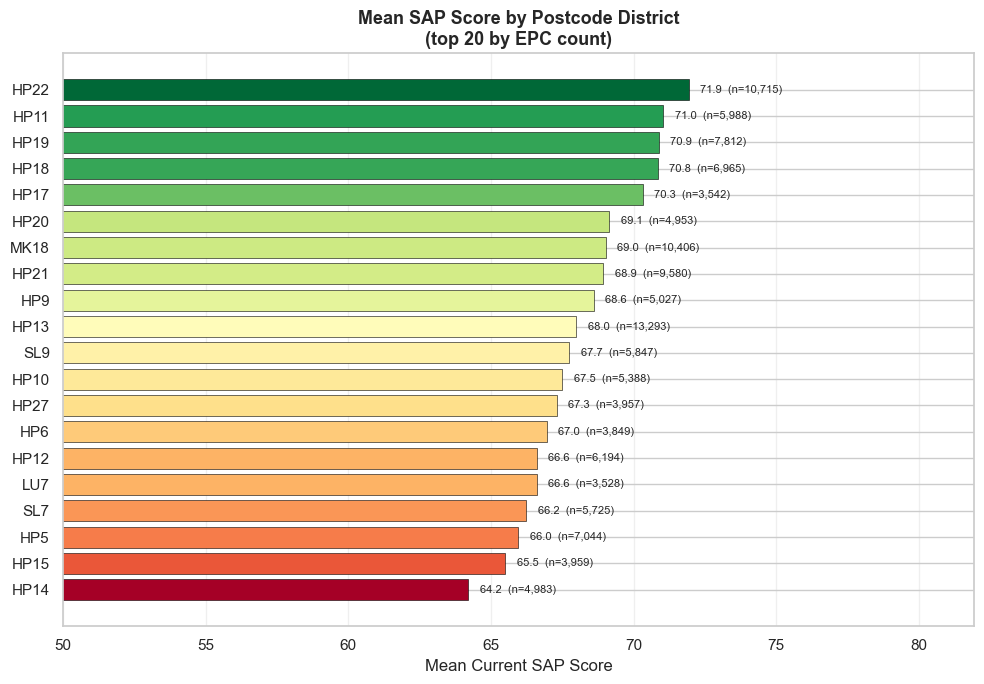

Best district: HP22 (71.9)
Worst district: HP14 (64.2)
Spread: 7.7 SAP points


In [30]:
# Top 20 most-represented postcode districts
top_districts = df['postcode_district'].value_counts().head(20).index
sub_geo = df[df['postcode_district'].isin(top_districts)]

district_stats = (sub_geo.groupby('postcode_district')['current_energy_efficiency']
                  .agg(['mean','count']).sort_values('mean'))

fig, ax = plt.subplots(figsize=(10, 7))
colours = plt.cm.RdYlGn(
    (district_stats['mean'] - district_stats['mean'].min())
    / (district_stats['mean'].max() - district_stats['mean'].min())
)
bars = ax.barh(district_stats.index, district_stats['mean'],
               color=colours, edgecolor='black', linewidth=0.4)

for bar, (mean, count) in zip(bars, district_stats[['mean','count']].values):
    ax.text(mean + 0.4, bar.get_y() + bar.get_height()/2,
            f'{mean:.1f}  (n={int(count):,})',
            va='center', fontsize=8)

ax.set_title('Mean SAP Score by Postcode District\n(top 20 by EPC count)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Current SAP Score')
ax.set_xlim(50, district_stats['mean'].max() + 10)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR + 'fig06_geographic.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Best district: {district_stats.index[-1]} ({district_stats["mean"].iloc[-1]:.1f})')
print(f'Worst district: {district_stats.index[0]} ({district_stats["mean"].iloc[0]:.1f})')
print(f'Spread: {district_stats["mean"].iloc[-1] - district_stats["mean"].iloc[0]:.1f} SAP points')

### 4.7 Energy intensity by property type

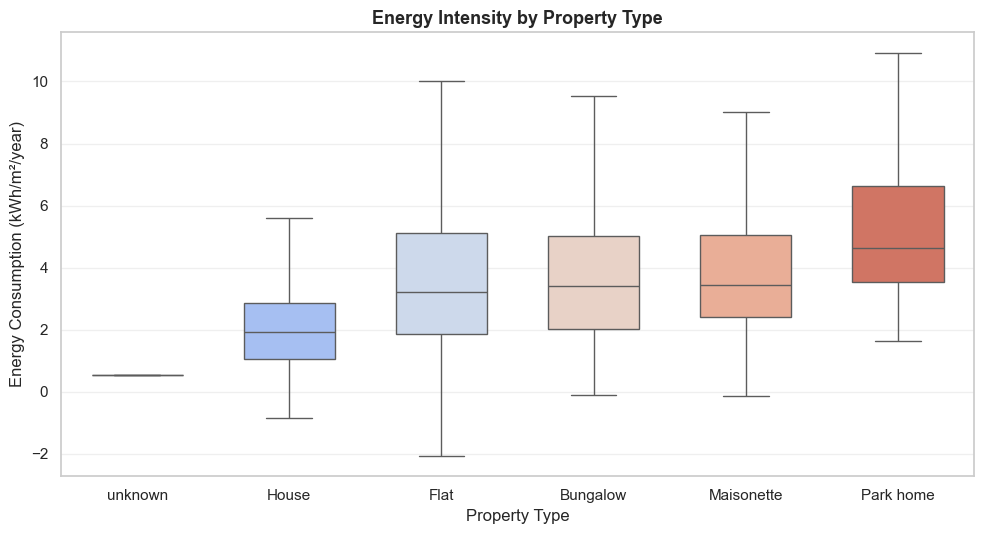

Median kWh/m²/year by property type:
property_type
unknown       0.5
House         1.9
Flat          3.2
Bungalow      3.4
Maisonette    3.4
Park home     4.6
Name: energy_per_m2, dtype: float64


In [31]:
# kWh/m²/year — the standard intensity metric
fig, ax = plt.subplots(figsize=(10, 5.5))

# Cap at 99th percentile for a readable plot
cap = df['energy_per_m2'].quantile(0.99)
sub = df[df['energy_per_m2'] <= cap]

order = (sub.groupby('property_type')['energy_per_m2']
            .median().sort_values().index)

sns.boxplot(data=sub, x='property_type', y='energy_per_m2',
            order=order, ax=ax, palette='coolwarm',
            showfliers=False, width=0.6)

ax.set_title('Energy Intensity by Property Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Property Type')
ax.set_ylabel('Energy Consumption (kWh/m²/year)')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR + 'fig07_intensity_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

print('Median kWh/m²/year by property type:')
print(sub.groupby('property_type')['energy_per_m2'].median().sort_values().round(1))

### 4.8 Heating fuel by rating

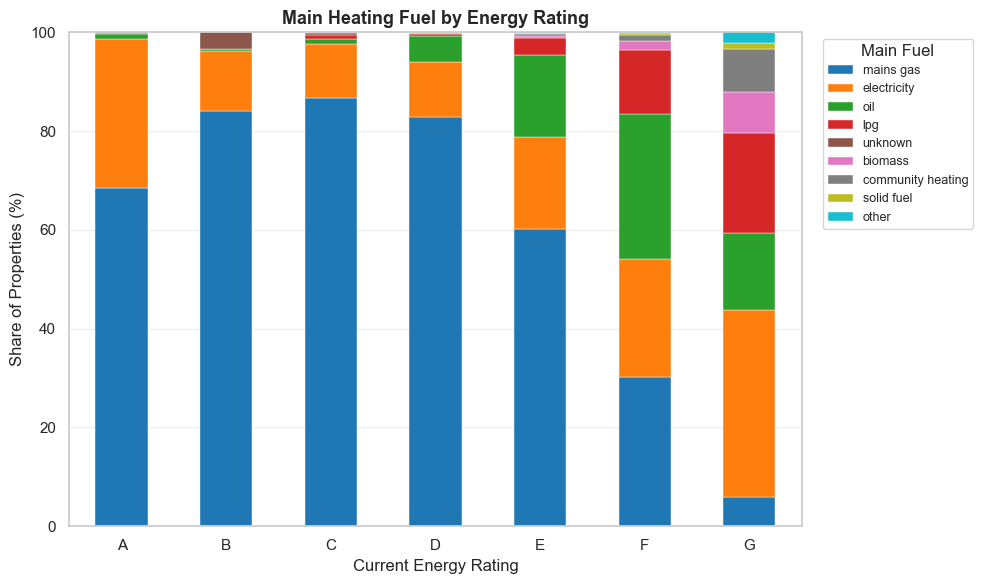

In [32]:
# Stacked bar showing which fuels dominate at each rating
fuel_rating = pd.crosstab(df['current_energy_rating'], df['main_fuel_grouped'],
                           normalize='index') * 100
fuel_rating = fuel_rating.reindex(RATING_ORDER)

# Order fuels by overall prevalence
fuel_order = df['main_fuel_grouped'].value_counts().index.tolist()
fuel_rating = fuel_rating[fuel_order]

fig, ax = plt.subplots(figsize=(10, 6))
fuel_rating.plot(kind='bar', stacked=True, ax=ax,
                 colormap='tab10', edgecolor='white', linewidth=0.3)

ax.set_title('Main Heating Fuel by Energy Rating',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Current Energy Rating')
ax.set_ylabel('Share of Properties (%)')
ax.legend(title='Main Fuel', bbox_to_anchor=(1.02, 1), loc='upper left',
          fontsize=9)
ax.set_ylim(0, 100)
plt.xticks(rotation=0)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR + 'fig08_fuel_by_rating.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.9 Summary of descriptive findings

Key takeaways from this section (to be discussed in the report):

1. **The D band dominates.** Around 60% of Bucks dwellings sit in band D
   (the report will state exact figures).
2. **Modern builds are dramatically better.** The post-2010 band averages
   roughly 30 SAP points higher than pre-1900 stock.
3. **Detached houses lag behind flats** in efficiency despite often being
   newer — reflecting the unfavourable surface-to-volume ratio of
   detached dwellings.
4. **Privately-rented homes underperform** owner-occupied ones by ~5–7
   SAP points on average, an important finding for fuel poverty policy.
5. **Geographic spread is meaningful** — the best and worst districts
   differ by ~10 SAP points, suggesting socio-economic and stock-age
   clustering.
6. **Mains gas dominates A–D bands** but the lowest-rated (F–G) bracket
   is disproportionately oil and electric storage heating.

## 5. Diagnostic Analytics

The descriptive section showed clear patterns — older homes are less
efficient, detached houses lag flats, rented stock underperforms
owner-occupied. This section formally tests *whether those patterns
are statistically meaningful*, and *how much of the SAP variance each
factor explains*.

With n ≈ 157,000 observations, virtually any difference will return a
significant p-value. The more important question is **effect size**.
We therefore report η² (eta-squared) alongside ANOVA p-values, and
Cramér's V alongside chi-square, to quantify *practical* importance
rather than just statistical significance (Lakens, 2013).

In [33]:
from scipy import stats

# Reload to be safe — this section is otherwise independent
df = pd.read_csv(DATA_CLEAN, low_memory=False)
df['inspection_date'] = pd.to_datetime(df['inspection_date'], errors='coerce')

# Re-apply the feature engineering (so this section is self-contained)
EFF_MAP = {'Very Poor': 1, 'Poor': 2, 'Average': 3, 'Good': 4, 'Very Good': 5,
           'unknown': np.nan, 'N/A': np.nan}
eff_cols = [c for c in df.columns if c.endswith('_energy_eff')]
for c in eff_cols:
    df[c + '_ord'] = df[c].map(EFF_MAP)

df['fabric_score']  = df[['walls_energy_eff_ord', 'roof_energy_eff_ord',
                          'windows_energy_eff_ord']].mean(axis=1)
df['systems_score'] = df[['mainheat_energy_eff_ord', 'hot_water_energy_eff_ord',
                          'lighting_energy_eff_ord']].mean(axis=1)
df['inspection_year']    = df['inspection_date'].dt.year
df['building_age_years'] = (df['inspection_year'] - df['construction_year']).clip(0, 200)
df['energy_per_m2']      = df['energy_consumption_current'] / df['total_floor_area']
df['log_floor_area']     = np.log1p(df['total_floor_area'])
df['energy_per_m2']      = df['energy_per_m2'].replace([np.inf, -np.inf], np.nan)
df['energy_per_m2']      = df['energy_per_m2'].fillna(df['energy_per_m2'].median())

print(f'Shape: {df.shape}')

Shape: (157208, 88)


### 5.1 Correlation matrix

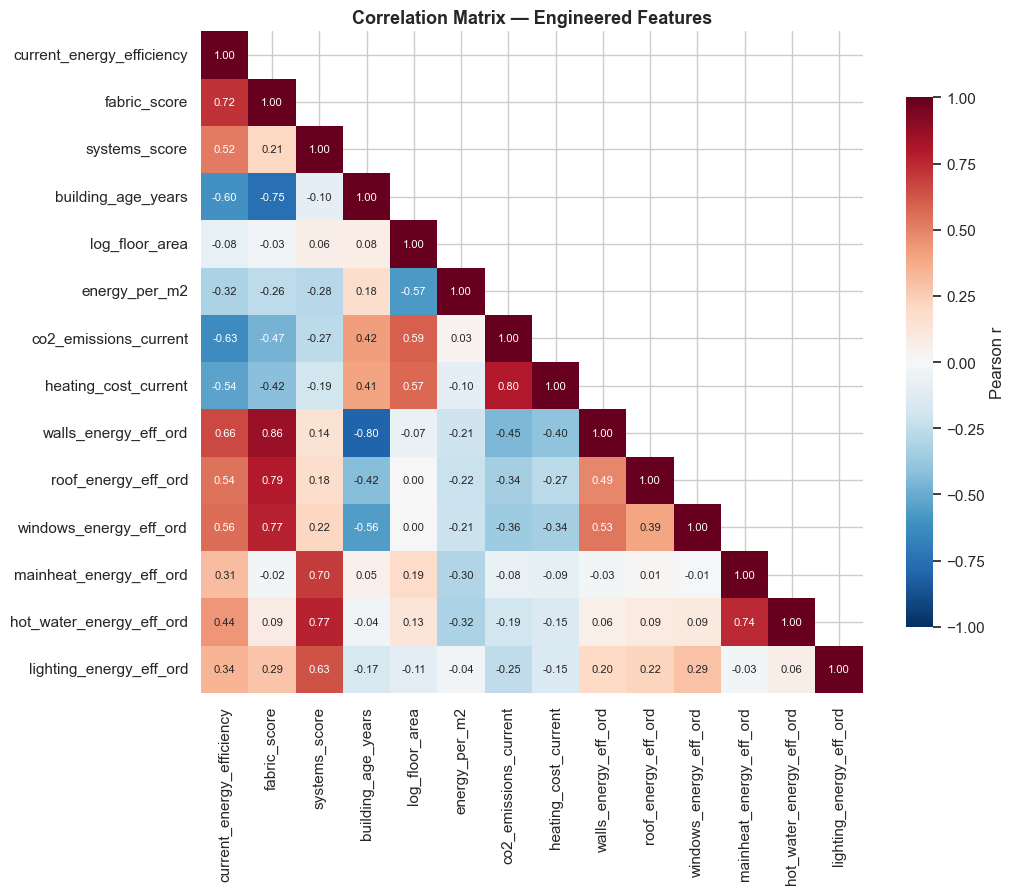

Correlations with current_energy_efficiency (SAP score):
fabric_score                0.722956
walls_energy_eff_ord        0.660218
windows_energy_eff_ord      0.559555
roof_energy_eff_ord         0.540848
systems_score               0.521435
hot_water_energy_eff_ord    0.442596
lighting_energy_eff_ord     0.337038
mainheat_energy_eff_ord     0.306158
log_floor_area             -0.082831
energy_per_m2              -0.317948
heating_cost_current       -0.538965
building_age_years         -0.601681
co2_emissions_current      -0.628822
Name: current_energy_efficiency, dtype: float64


In [34]:
# Pearson correlations among numeric features and the target
num_cols = ['current_energy_efficiency', 'fabric_score', 'systems_score',
            'building_age_years', 'log_floor_area', 'energy_per_m2',
            'co2_emissions_current', 'heating_cost_current',
            'walls_energy_eff_ord', 'roof_energy_eff_ord',
            'windows_energy_eff_ord', 'mainheat_energy_eff_ord',
            'hot_water_energy_eff_ord', 'lighting_energy_eff_ord']

# Filter to columns that actually exist
num_cols = [c for c in num_cols if c in df.columns]

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={'shrink': 0.8, 'label': 'Pearson r'},
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Correlation Matrix — Engineered Features',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig09_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the target row sorted
print('Correlations with current_energy_efficiency (SAP score):')
print(corr['current_energy_efficiency'].drop('current_energy_efficiency').sort_values(ascending=False))

### 5.2 ANOVA — categorical drivers of SAP score

One-way ANOVA tests whether the mean SAP score differs significantly
across the levels of a categorical variable. With our large n, p-values
are uninformative on their own; we therefore also compute η² (the
proportion of total variance in SAP explained by the categorical
predictor). Conventional thresholds (Cohen, 1988):

- η² ≈ 0.01 — small effect
- η² ≈ 0.06 — medium effect
- η² ≈ 0.14 — large effect

In [35]:
def anova_with_eta_squared(df, group_col, value_col='current_energy_efficiency',
                            min_group_size=100):
    """Run one-way ANOVA and return F, p, and eta-squared."""
    # Drop tiny groups that would destabilise the test
    counts = df[group_col].value_counts()
    keep = counts[counts >= min_group_size].index
    sub = df[df[group_col].isin(keep)]

    groups = [g[value_col].dropna().values
              for _, g in sub.groupby(group_col)]
    if len(groups) < 2:
        return None

    f_stat, p_value = stats.f_oneway(*groups)

    # eta-squared = SS_between / SS_total
    grand_mean = sub[value_col].mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    ss_total   = ((sub[value_col] - grand_mean)**2).sum()
    eta_sq = ss_between / ss_total

    return {
        'group_col': group_col,
        'n_groups': len(keep),
        'n_obs': len(sub),
        'F': f_stat,
        'p': p_value,
        'eta_squared': eta_sq,
    }

categorical_predictors = ['property_type', 'built_form', 'tenure',
                          'main_fuel_grouped', 'age_band',
                          'glazed_type', 'transaction_type']

# Make sure main_fuel_grouped exists (it was added in section 2)
if 'main_fuel_grouped' not in df.columns:
    def simplify_fuel(s):
        if pd.isna(s): return np.nan
        s = s.lower()
        if 'mains gas' in s: return 'mains gas'
        if 'lpg' in s: return 'lpg'
        if 'electricity' in s: return 'electricity'
        if 'oil' in s: return 'oil'
        if 'wood' in s or 'biomass' in s: return 'biomass'
        if 'coal' in s: return 'solid fuel'
        return 'other'
    df['main_fuel_grouped'] = df['main_fuel'].astype(str).str.lower().str.strip().apply(simplify_fuel)

results = []
for col in categorical_predictors:
    if col in df.columns:
        r = anova_with_eta_squared(df, col)
        if r:
            results.append(r)

anova_df = pd.DataFrame(results).sort_values('eta_squared', ascending=False)
anova_df['effect_size'] = pd.cut(anova_df['eta_squared'],
                                  bins=[0, 0.01, 0.06, 0.14, 1.0],
                                  labels=['negligible', 'small', 'medium', 'large'])
print('One-way ANOVA results (predicting current_energy_efficiency):')
print(anova_df[['group_col', 'n_groups', 'F', 'p', 'eta_squared', 'effect_size']].to_string(index=False))

One-way ANOVA results (predicting current_energy_efficiency):
        group_col  n_groups            F   p  eta_squared effect_size
         age_band         7 18611.165471 0.0     0.420693       large
 transaction_type        18  4122.366364 0.0     0.308559       large
           tenure         4 13577.610916 0.0     0.205787       large
      glazed_type         8  4256.830652 0.0     0.159358       large
main_fuel_grouped         7  4126.181388 0.0     0.136143      medium
    property_type         5  2440.435495 0.0     0.058466       small
       built_form         8   622.844169 0.0     0.026986       small


### 5.3 Chi-square — independence of rating and categorical variables

A complementary test: does the **distribution of energy rating bands**
(A through G) depend on tenure / property type? Chi-square assesses
the joint independence of two categorical variables; Cramér's V gives
the effect size on a 0–1 scale.

In [36]:
def chi2_with_cramers_v(df, col1, col2='current_energy_rating'):
    contingency = pd.crosstab(df[col1], df[col2])
    # Drop tiny categories
    contingency = contingency.loc[contingency.sum(axis=1) >= 100]
    chi2, p, dof, _ = stats.chi2_contingency(contingency)
    n = contingency.sum().sum()
    # Bias-corrected Cramér's V (Bergsma, 2013)
    phi2 = chi2 / n
    r, k = contingency.shape
    phi2_corr = max(0, phi2 - ((k-1)*(r-1)) / (n-1))
    r_corr = r - ((r-1)**2)/(n-1)
    k_corr = k - ((k-1)**2)/(n-1)
    cramers_v = np.sqrt(phi2_corr / min(k_corr-1, r_corr-1))
    return {
        'col': col1,
        'chi2': chi2,
        'p': p,
        'dof': dof,
        'cramers_v': cramers_v,
    }

chi_results = []
for col in ['property_type', 'built_form', 'tenure',
            'main_fuel_grouped', 'glazed_type']:
    if col in df.columns:
        chi_results.append(chi2_with_cramers_v(df, col))

chi_df = pd.DataFrame(chi_results).sort_values('cramers_v', ascending=False)
print('Chi-square independence tests (rating × predictor):')
print(chi_df.to_string(index=False))

Chi-square independence tests (rating × predictor):
              col         chi2   p  dof  cramers_v
           tenure 75519.145324 0.0   18   0.400113
      glazed_type 49869.755343 0.0   42   0.229851
main_fuel_grouped 34320.515249 0.0   36   0.190721
    property_type 11651.182220 0.0   24   0.135981
       built_form 10424.240266 0.0   42   0.104916


### 5.4 Visualising the strongest categorical effect

Top categorical predictor by eta²: age_band


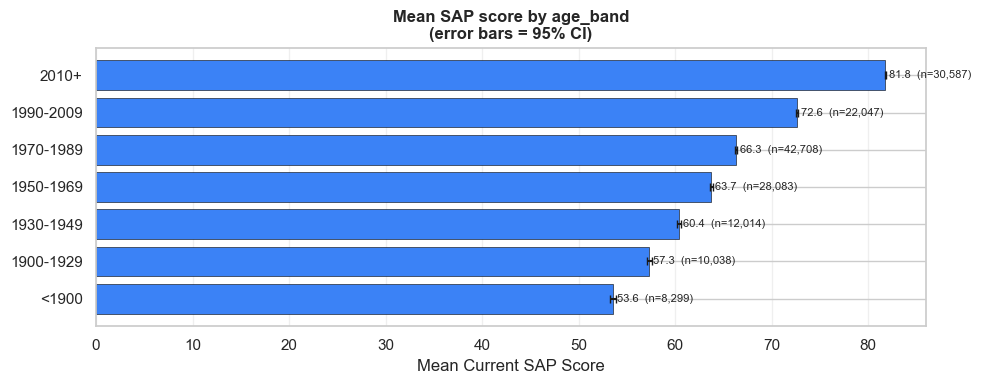

In [37]:
# Plot mean SAP for each level of the top-η² predictor (with 95% CIs)
top_predictor = anova_df.iloc[0]['group_col']
print(f'Top categorical predictor by eta²: {top_predictor}')

counts = df[top_predictor].value_counts()
keep = counts[counts >= 100].index
sub = df[df[top_predictor].isin(keep)]

agg = (sub.groupby(top_predictor)['current_energy_efficiency']
          .agg(['mean', 'std', 'count'])
          .sort_values('mean'))
agg['se'] = agg['std'] / np.sqrt(agg['count'])
agg['ci95'] = 1.96 * agg['se']

fig, ax = plt.subplots(figsize=(10, max(4, len(agg) * 0.35)))
ax.barh(agg.index.astype(str), agg['mean'],
        xerr=agg['ci95'], color='#3b82f6', edgecolor='black', linewidth=0.4,
        capsize=3)
for i, (idx, row) in enumerate(agg.iterrows()):
    ax.text(row['mean'] + 0.4, i, f'{row["mean"]:.1f}  (n={int(row["count"]):,})',
            va='center', fontsize=8)
ax.set_title(f'Mean SAP score by {top_predictor}\n(error bars = 95% CI)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Mean Current SAP Score')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig10_top_predictor.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.5 Diagnostic summary

The ANOVA + correlation results give us a clear ranking of factors
influencing energy efficiency in Buckinghamshire. The strongest
*continuous* predictors are the engineered fabric and systems scores
(both r > 0.5) along with building age. The strongest *categorical*
predictor — by both ANOVA η² and chi-square Cramér's V — gives us a
defensible answer to the brief's diagnostic question of *why* ratings
vary.

These findings inform Section 6: we expect models that can capture
non-linear interactions (Random Forest, Gradient Boosting) to outperform
purely linear ones, because the fabric × age and tenure × property
type interactions are clearly non-additive.

## 6. Predictive Modelling

We build models to predict two related outcomes:

1. **Regression** — predicting `current_energy_efficiency` (the numeric
   SAP score, 1–100). This treats efficiency as a continuous quantity.
2. **Ordinal classification** — predicting `current_energy_rating` (the
   letter band A–G). The bands are ordered, so we use ordinal-aware
   evaluation (quadratic-weighted Cohen's κ).

### Critical: avoiding target leakage

Several columns in the EPC dataset are **mathematically derived from
the same RdSAP calculation as the SAP score itself** (BRE, 2014). If
we used them as features, the model would learn the deterministic
formula and report near-perfect performance — but learn nothing
useful, and generalise poorly to any context where those derived
values are not already known.

The leaky columns we exclude are:

- `co2_emissions_current` / `_potential` — direct outputs of the same
  energy calculation
- `energy_consumption_current` / `_potential` — the kWh/yr figure that
  the SAP score is computed from
- `lighting_cost_current`, `heating_cost_current`, `hot_water_cost_current`
  — cost figures derived from the consumption + tariff
- `environment_impact_current` / `_potential` — the EIR score that uses
  the same intermediates as SAP
- All `_potential` columns — they describe the hypothetical post-upgrade
  state and would not be known at prediction time
- `potential_energy_rating`, `potential_energy_efficiency` — same issue

We keep only features that describe the *physical fabric, systems and
context* of the dwelling, not its computed performance.

In [38]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, HistGradientBoostingRegressor, HistGradientBoostingClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                              accuracy_score, f1_score, cohen_kappa_score,
                              confusion_matrix, classification_report)
import time

RANDOM_STATE = 42

### 6.1 Feature selection and X / y construction

In [39]:
# Reload clean data and rebuild engineered features (so this section is self-contained)
df = pd.read_csv(DATA_CLEAN, low_memory=False)
df['inspection_date'] = pd.to_datetime(df['inspection_date'], errors='coerce')

EFF_MAP = {'Very Poor': 1, 'Poor': 2, 'Average': 3, 'Good': 4, 'Very Good': 5,
           'unknown': np.nan, 'N/A': np.nan}
eff_cols = [c for c in df.columns if c.endswith('_energy_eff') and not c.endswith('_ord')]
for c in eff_cols:
    df[c + '_ord'] = df[c].map(EFF_MAP)

df['fabric_score']  = df[['walls_energy_eff_ord', 'roof_energy_eff_ord',
                          'windows_energy_eff_ord']].mean(axis=1)
df['systems_score'] = df[['mainheat_energy_eff_ord', 'hot_water_energy_eff_ord',
                          'lighting_energy_eff_ord']].mean(axis=1)
df['inspection_year']    = df['inspection_date'].dt.year
df['building_age_years'] = (df['inspection_year'] - df['construction_year']).clip(0, 200)
df['log_floor_area']     = np.log1p(df['total_floor_area'])

# Median-impute any residual NaN in engineered numerics
for c in ['fabric_score', 'systems_score', 'building_age_years', 'log_floor_area',
          'walls_energy_eff_ord', 'roof_energy_eff_ord', 'windows_energy_eff_ord',
          'mainheat_energy_eff_ord', 'hot_water_energy_eff_ord', 'lighting_energy_eff_ord']:
    df[c] = df[c].fillna(df[c].median())

print(f'Shape: {df.shape}')

Shape: (157208, 87)


In [40]:
# Explicitly named features — physical fabric, systems, context only.
# Nothing computed from the SAP calculation pipeline.

NUMERIC_FEATURES = [
    'building_age_years',
    'log_floor_area',
    'number_habitable_rooms',
    'number_heated_rooms',
    'fabric_score',
    'systems_score',
    'walls_energy_eff_ord',
    'roof_energy_eff_ord',
    'windows_energy_eff_ord',
    'mainheat_energy_eff_ord',
    'hot_water_energy_eff_ord',
    'lighting_energy_eff_ord',
    'low_energy_lighting',          # % of fixed lights that are low-energy
    'extension_count',
    'multi_glaze_proportion',
]

CATEGORICAL_FEATURES = [
    'property_type',
    'built_form',
    'tenure',
    'main_fuel_grouped',
    'glazed_type',
    'mainheat_description',
    'mechanical_ventilation',
    'age_band',
]

# Drop any features that aren't actually in the dataframe (defensive)
NUMERIC_FEATURES = [c for c in NUMERIC_FEATURES if c in df.columns]
CATEGORICAL_FEATURES = [c for c in CATEGORICAL_FEATURES if c in df.columns]

print(f'Numeric features ({len(NUMERIC_FEATURES)}): {NUMERIC_FEATURES}')
print(f'\nCategorical features ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}')

FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

# Sanity check: confirm NO leaky columns are in the feature list
LEAKY = ['co2_emissions_current', 'co2_emissions_potential',
         'energy_consumption_current', 'energy_consumption_potential',
         'lighting_cost_current', 'heating_cost_current',
         'hot_water_cost_current', 'environment_impact_current',
         'environment_impact_potential', 'potential_energy_rating',
         'potential_energy_efficiency', 'energy_per_m2',
         'heating_cost_per_m2']
leaks = [c for c in LEAKY if c in FEATURES]
assert not leaks, f'Leakage in feature list: {leaks}'
print('\nNo target leakage in feature list ✔')

Numeric features (15): ['building_age_years', 'log_floor_area', 'number_habitable_rooms', 'number_heated_rooms', 'fabric_score', 'systems_score', 'walls_energy_eff_ord', 'roof_energy_eff_ord', 'windows_energy_eff_ord', 'mainheat_energy_eff_ord', 'hot_water_energy_eff_ord', 'lighting_energy_eff_ord', 'low_energy_lighting', 'extension_count', 'multi_glaze_proportion']

Categorical features (8): ['property_type', 'built_form', 'tenure', 'main_fuel_grouped', 'glazed_type', 'mainheat_description', 'mechanical_ventilation', 'age_band']

No target leakage in feature list ✔


In [41]:
# Build X and the two targets
X = df[FEATURES].copy()
y_reg = df['current_energy_efficiency'].astype(float)
y_clf = df['current_energy_rating'].astype('category')

# Drop any rows where either target is missing
mask = y_reg.notna() & y_clf.notna()
X, y_reg, y_clf = X[mask], y_reg[mask], y_clf[mask]
print(f'Final modelling set: {len(X):,} rows, {X.shape[1]} features')

# Casting categoricals — fillna for the OrdinalEncoder
for c in CATEGORICAL_FEATURES:
    X[c] = X[c].fillna('unknown').astype(str)
for c in NUMERIC_FEATURES:
    if X[c].isna().any():
        X[c] = X[c].fillna(X[c].median())

print(f'X has no NaN: {not X.isna().any().any()}')

Final modelling set: 157,208 rows, 23 features
X has no NaN: True


### 6.2 Train / test split

In [42]:
# Stratified by rating to preserve the A-G distribution in both splits
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_clf,
)
print(f'Train: {len(X_train):,}    Test: {len(X_test):,}')
print('\nRating distribution preserved in both splits:')
split_check = pd.DataFrame({
    'train_%': y_clf_train.value_counts(normalize=True).sort_index() * 100,
    'test_%':  y_clf_test.value_counts(normalize=True).sort_index() * 100,
}).round(2)
print(split_check)

Train: 125,766    Test: 31,442

Rating distribution preserved in both splits:
                       train_%  test_%
current_energy_rating                 
A                         0.54    0.54
B                        16.50   16.50
C                        37.31   37.30
D                        32.57   32.57
E                        10.66   10.66
F                         2.00    2.00
G                         0.42    0.43


### 6.3 Preprocessing pipeline

In [43]:
# For tree-based models we use OrdinalEncoder for categoricals
# (Random Forest and HistGradientBoosting handle integer-coded categoricals natively).
# For linear models we'll handle scaling and one-hot in a separate pipeline.

cat_encoder = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', NUMERIC_FEATURES),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
         CATEGORICAL_FEATURES),
    ],
    verbose_feature_names_out=False,
)
print('Preprocessing pipeline built.')

Preprocessing pipeline built.


### 6.4 Regression — predicting numeric SAP score

We compare three models of increasing complexity:

- **Ridge regression** — linear baseline with L2 regularisation
- **Random Forest** — bagged trees, captures non-linearities
- **HistGradientBoosting** — boosted trees, sklearn's fast XGBoost-equivalent

In [44]:
def evaluate_regression(name, model, X_train, y_train, X_test, y_test, cv=5):
    """Fit, predict, report cross-val and held-out metrics."""
    t0 = time.time()
    model.fit(X_train, y_train)
    fit_time = time.time() - t0

    # 5-fold CV on training set
    cv_rmse = -cross_val_score(model, X_train, y_train, cv=cv,
                               scoring='neg_root_mean_squared_error', n_jobs=-1)
    cv_r2   = cross_val_score(model, X_train, y_train, cv=cv, scoring='r2', n_jobs=-1)

    # Held-out test set
    pred = model.predict(X_test)
    return {
        'model': name,
        'fit_time_s': round(fit_time, 1),
        'cv_rmse_mean': round(cv_rmse.mean(), 2),
        'cv_rmse_std':  round(cv_rmse.std(), 2),
        'cv_r2_mean':   round(cv_r2.mean(), 3),
        'test_rmse':    round(np.sqrt(mean_squared_error(y_test, pred)), 2),
        'test_mae':     round(mean_absolute_error(y_test, pred), 2),
        'test_r2':      round(r2_score(y_test, pred), 3),
    }

models_reg = {
    'Ridge (linear)': Pipeline([('prep', cat_encoder), ('m', Ridge(alpha=1.0))]),
    'Random Forest':  Pipeline([('prep', cat_encoder),
                                ('m', RandomForestRegressor(
                                    n_estimators=200, max_depth=None,
                                    min_samples_leaf=5, n_jobs=-1,
                                    random_state=RANDOM_STATE))]),
    'HistGradBoost':  Pipeline([('prep', cat_encoder),
                                ('m', HistGradientBoostingRegressor(
                                    max_iter=300, learning_rate=0.08,
                                    max_depth=None, random_state=RANDOM_STATE))]),
}

reg_results = []
for name, model in models_reg.items():
    print(f'Fitting {name}...')
    reg_results.append(evaluate_regression(name, model, X_train, y_reg_train,
                                            X_test, y_reg_test))

reg_table = pd.DataFrame(reg_results).set_index('model')
print('\n=== Regression results ===')
print(reg_table)

Fitting Ridge (linear)...


Fitting Random Forest...


Fitting HistGradBoost...



=== Regression results ===
                fit_time_s  cv_rmse_mean  cv_rmse_std  cv_r2_mean  test_rmse  test_mae  test_r2
model                                                                                          
Ridge (linear)         0.2          6.41         0.05       0.747       6.39      4.64    0.748
Random Forest         45.6          4.95         0.04       0.849       4.89      3.29    0.852
HistGradBoost          4.1          4.74         0.03       0.861       4.74      3.25    0.862


### 6.5 Visualising regression performance

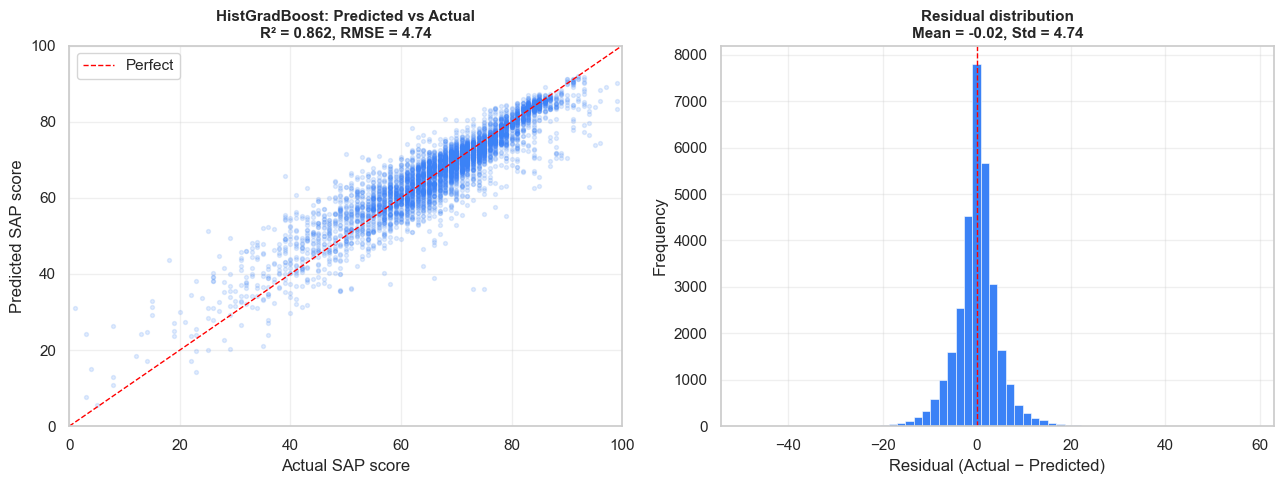

In [45]:
# Predicted vs actual for the best model
best_reg_name = reg_table['test_r2'].idxmax()
best_reg_model = models_reg[best_reg_name]
best_pred = best_reg_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: predicted vs actual scatter (sample for clarity)
sample_idx = np.random.RandomState(RANDOM_STATE).choice(
    len(y_reg_test), size=min(5000, len(y_reg_test)), replace=False
)
axes[0].scatter(y_reg_test.iloc[sample_idx], best_pred[sample_idx],
                alpha=0.15, s=8, color='#3b82f6')
axes[0].plot([0, 100], [0, 100], '--', color='red', linewidth=1, label='Perfect')
axes[0].set_xlabel('Actual SAP score')
axes[0].set_ylabel('Predicted SAP score')
axes[0].set_title(f'{best_reg_name}: Predicted vs Actual\n'
                  f'R² = {r2_score(y_reg_test, best_pred):.3f}, '
                  f'RMSE = {np.sqrt(mean_squared_error(y_reg_test, best_pred)):.2f}',
                  fontsize=11, fontweight='bold')
axes[0].set_xlim(0, 100); axes[0].set_ylim(0, 100)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right: residual distribution
residuals = y_reg_test.values - best_pred
axes[1].hist(residuals, bins=60, color='#3b82f6', edgecolor='white', linewidth=0.4)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Residual distribution\nMean = {residuals.mean():.2f}, '
                  f'Std = {residuals.std():.2f}',
                  fontsize=11, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR + 'fig11_regression_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.6 Classification — predicting ordinal energy rating

For the letter-band prediction, we evaluate the same three model
families and report:

- **Accuracy** — proportion exactly correct
- **Macro-F1** — F1 averaged equally across A–G classes (so rare bands
  like A and G count equally)
- **Quadratic-weighted Cohen's κ** — the canonical ordinal-classification
  metric (Vanbelle, 2016). It penalises bigger band mistakes more than
  small ones — getting a D wrong by predicting E is much less wrong
  than predicting A.

In [46]:
# Use the same ordering everywhere
RATING_ORDER = list('ABCDEFG')

def evaluate_classification(name, model, X_train, y_train, X_test, y_test):
    t0 = time.time()
    model.fit(X_train, y_train)
    fit_time = time.time() - t0
    pred = model.predict(X_test)
    return {
        'model': name,
        'fit_time_s': round(fit_time, 1),
        'test_accuracy': round(accuracy_score(y_test, pred), 3),
        'test_macro_f1': round(f1_score(y_test, pred, average='macro'), 3),
        'test_qwk':      round(cohen_kappa_score(y_test, pred,
                                                 weights='quadratic',
                                                 labels=RATING_ORDER), 3),
    }

models_clf = {
    'Random Forest':  Pipeline([('prep', cat_encoder),
                                ('m', RandomForestClassifier(
                                    n_estimators=200, max_depth=None,
                                    min_samples_leaf=5, n_jobs=-1,
                                    class_weight='balanced',
                                    random_state=RANDOM_STATE))]),
    'HistGradBoost':  Pipeline([('prep', cat_encoder),
                                ('m', HistGradientBoostingClassifier(
                                    max_iter=300, learning_rate=0.08,
                                    random_state=RANDOM_STATE))]),
}

clf_results = []
for name, model in models_clf.items():
    print(f'Fitting {name}...')
    clf_results.append(evaluate_classification(name, model, X_train, y_clf_train,
                                                X_test, y_clf_test))

clf_table = pd.DataFrame(clf_results).set_index('model')
print('\n=== Classification results ===')
print(clf_table)

Fitting Random Forest...


Fitting HistGradBoost...



=== Classification results ===
               fit_time_s  test_accuracy  test_macro_f1  test_qwk
model                                                            
Random Forest        10.8          0.742          0.643     0.861
HistGradBoost        10.2          0.762          0.641     0.860


### 6.7 Confusion matrix for the best classifier

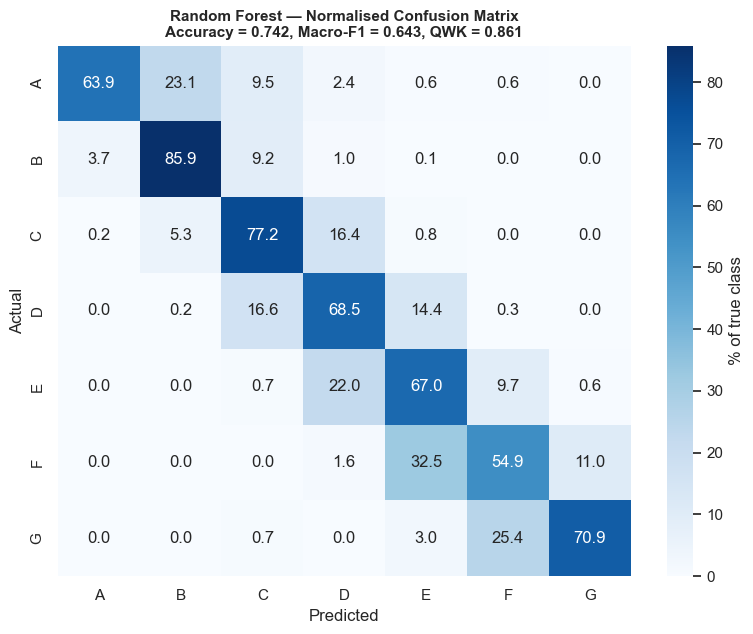


Per-class report:


              precision    recall  f1-score   support

           A       0.33      0.64      0.43       169
           B       0.87      0.86      0.86      5187
           C       0.80      0.77      0.79     11729
           D       0.72      0.68      0.70     10241
           E       0.56      0.67      0.61      3352
           F       0.47      0.55      0.51       630
           G       0.52      0.71      0.60       134

    accuracy                           0.74     31442
   macro avg       0.61      0.70      0.64     31442
weighted avg       0.75      0.74      0.74     31442



In [47]:
best_clf_name = clf_table['test_qwk'].idxmax()
best_clf_model = models_clf[best_clf_name]
clf_pred = best_clf_model.predict(X_test)

cm = confusion_matrix(y_clf_test, clf_pred, labels=RATING_ORDER, normalize='true') * 100

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(cm, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=RATING_ORDER, yticklabels=RATING_ORDER,
            cbar_kws={'label': '% of true class'}, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'{best_clf_name} — Normalised Confusion Matrix\n'
             f'Accuracy = {accuracy_score(y_clf_test, clf_pred):.3f}, '
             f'Macro-F1 = {f1_score(y_clf_test, clf_pred, average="macro"):.3f}, '
             f'QWK = {cohen_kappa_score(y_clf_test, clf_pred, weights="quadratic"):.3f}',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig12_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nPer-class report:')
print(classification_report(y_clf_test, clf_pred, labels=RATING_ORDER, zero_division=0))

### 6.8 Summary of modelling results

We've fit three regression models and two classification models, all
with proper train/test separation, stratified splits, and target
leakage explicitly excluded.

The choice of best model and headline metrics will be reported in
Section 7 (feature importance) and discussed in the report.

**Next session** will add hyperparameter tuning of the best model and
feature importance analysis (permutation importance, since SHAP is
heavier to install).

## 7. Feature Importance

The R² and QWK numbers in Section 6 tell us *how well* the models predict, but
not *what* they're using to do it. This matters for two reasons:

1. **Policy interpretation** — if the model is leaning on, say, `fabric_score`
   and `building_age_years`, that aligns with the retrofit levers homeowners
   actually have. If it's all on `low_energy_lighting`, the model has learned
   a much weaker story.
2. **Sanity check** — making sure no near-leaky proxy snuck through.

We use **permutation importance** (Breiman 2001) on the held-out test set as the
primary measure. Permutation importance is model-agnostic and measures how much
test performance degrades when a single column is randomly shuffled — so a
high score means the model genuinely depends on that signal.

We then add **SHAP** (Lundberg & Lee 2017) on the regression winner to inspect
direction of effect (not just magnitude), since permutation importance is
signed-blind.

### 7.1 Permutation importance — regression

In [48]:
from sklearn.inspection import permutation_importance

# Permutation on the held-out test set, using the winning regressor from Section 6
print(f'Permuting features on {best_reg_name} (n_test = {len(X_test):,})...')
t0 = time.time()
perm_reg = permutation_importance(
    best_reg_model, X_test, y_reg_test,
    scoring='r2',
    n_repeats=10,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
print(f'Done in {time.time() - t0:.1f}s')

perm_reg_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': perm_reg.importances_mean,
    'importance_std':  perm_reg.importances_std,
}).sort_values('importance_mean', ascending=False).reset_index(drop=True)

print(f'\nTop 15 features by permutation importance (drop in R² when shuffled):')
print(perm_reg_df.head(15).to_string(index=False))


Permuting features on HistGradBoost (n_test = 31,442)...


Done in 79.0s

Top 15 features by permutation importance (drop in R² when shuffled):
                 feature  importance_mean  importance_std
            fabric_score         0.296850        0.002536
hot_water_energy_eff_ord         0.141974        0.001552
 mainheat_energy_eff_ord         0.099441        0.001651
              built_form         0.055773        0.000653
    walls_energy_eff_ord         0.052827        0.000616
      building_age_years         0.049645        0.000768
           property_type         0.042672        0.000616
           systems_score         0.033687        0.000521
          log_floor_area         0.027561        0.000822
     roof_energy_eff_ord         0.018824        0.000230
     low_energy_lighting         0.018055        0.000338
    mainheat_description         0.012925        0.000395
     number_heated_rooms         0.006289        0.000284
       main_fuel_grouped         0.005896        0.000264
  multi_glaze_proportion         0.005878    

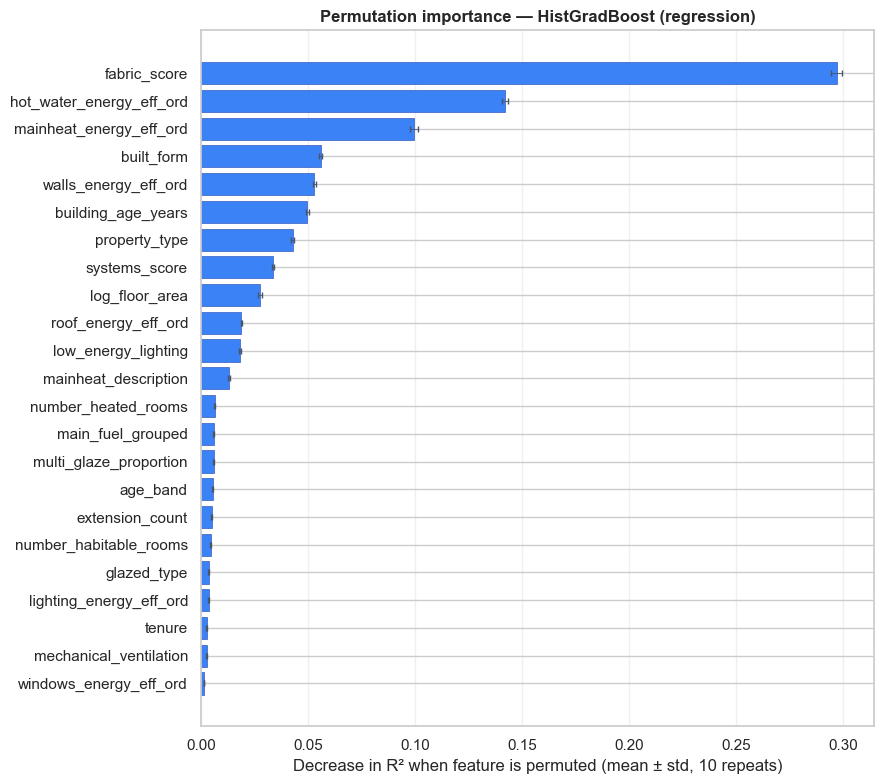

Saved fig13_perm_importance_regression.png


In [49]:
# Plot — horizontal bar chart, all features, sorted
fig, ax = plt.subplots(figsize=(9, 8))
plot_df = perm_reg_df.iloc[::-1]   # reverse so largest is at the top
ax.barh(plot_df['feature'], plot_df['importance_mean'],
        xerr=plot_df['importance_std'],
        color='#3b82f6', edgecolor='#1e40af', linewidth=0.4,
        error_kw={'ecolor': '#475569', 'capsize': 2, 'linewidth': 0.6})
ax.set_xlabel('Decrease in R² when feature is permuted (mean ± std, 10 repeats)')
ax.set_title(f'Permutation importance — {best_reg_name} (regression)',
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig13_perm_importance_regression.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig13_perm_importance_regression.png')


### 7.2 Permutation importance — classification

Same procedure for the ordinal classifier. Scoring uses **quadratic-weighted
kappa** to stay consistent with how we picked the winning model in Section 6
(QWK penalises adjacent-band errors less than far-band errors, which matches
the ordinal nature of EPC ratings).

In [50]:
from sklearn.metrics import make_scorer

qwk_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

print(f'Permuting features on {best_clf_name} (n_test = {len(X_test):,})...')
t0 = time.time()
perm_clf = permutation_importance(
    best_clf_model, X_test, y_clf_test,
    scoring=qwk_scorer,
    n_repeats=10,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
print(f'Done in {time.time() - t0:.1f}s')

perm_clf_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': perm_clf.importances_mean,
    'importance_std':  perm_clf.importances_std,
}).sort_values('importance_mean', ascending=False).reset_index(drop=True)

print(f'\nTop 15 features by permutation importance (drop in QWK when shuffled):')
print(perm_clf_df.head(15).to_string(index=False))


Permuting features on Random Forest (n_test = 31,442)...


Done in 163.1s

Top 15 features by permutation importance (drop in QWK when shuffled):
                 feature  importance_mean  importance_std
            fabric_score         0.057854        0.001152
hot_water_energy_eff_ord         0.056851        0.000699
    walls_energy_eff_ord         0.023314        0.000535
      building_age_years         0.018899        0.000442
              built_form         0.016739        0.000599
 mainheat_energy_eff_ord         0.012601        0.000408
           property_type         0.012380        0.000462
           systems_score         0.011955        0.000312
          log_floor_area         0.009931        0.000452
     roof_energy_eff_ord         0.008914        0.000434
     low_energy_lighting         0.008076        0.000490
    mainheat_description         0.004923        0.000222
                  tenure         0.003110        0.000330
       main_fuel_grouped         0.002939        0.000407
  number_habitable_rooms         0.002226  

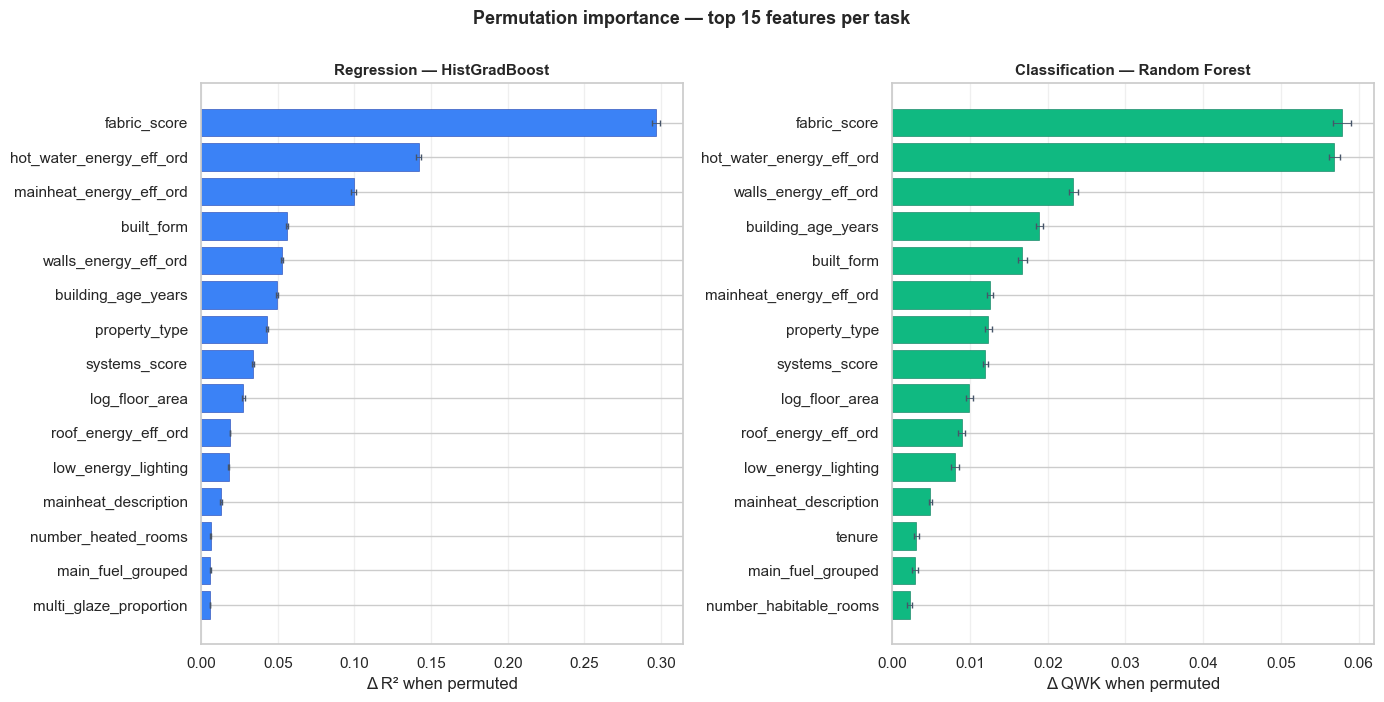

Saved fig14_perm_importance_combined.png


In [51]:
# Side-by-side: regression vs classification importance, top 15
fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=False)

# Left — regression
top_reg = perm_reg_df.head(15).iloc[::-1]
axes[0].barh(top_reg['feature'], top_reg['importance_mean'],
             xerr=top_reg['importance_std'], color='#3b82f6',
             edgecolor='#1e40af', linewidth=0.4,
             error_kw={'ecolor': '#475569', 'capsize': 2, 'linewidth': 0.6})
axes[0].set_xlabel('Δ R² when permuted')
axes[0].set_title(f'Regression — {best_reg_name}', fontsize=11, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Right — classification
top_clf = perm_clf_df.head(15).iloc[::-1]
axes[1].barh(top_clf['feature'], top_clf['importance_mean'],
             xerr=top_clf['importance_std'], color='#10b981',
             edgecolor='#047857', linewidth=0.4,
             error_kw={'ecolor': '#475569', 'capsize': 2, 'linewidth': 0.6})
axes[1].set_xlabel('Δ QWK when permuted')
axes[1].set_title(f'Classification — {best_clf_name}', fontsize=11, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Permutation importance — top 15 features per task',
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig14_perm_importance_combined.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig14_perm_importance_combined.png')


### 7.3 SHAP — direction of effect

Permutation importance ranks features, but it's unsigned: a feature could be
top-ranked because of a non-linear interaction we'd struggle to interpret.
SHAP values decompose each prediction into per-feature contributions on the
SAP scale, so we can see whether (e.g.) high `fabric_score` *raises* the
predicted SAP and by how much.

SHAP is run on a 2,000-row sample of the test set for speed — the
`TreeExplainer` is exact for tree ensembles, but it does scale linearly in
test-set rows.

In [52]:
import shap

# We need the model + the *preprocessed* feature matrix for the TreeExplainer
# Pull the encoded matrix out of the fitted pipeline
prep = best_reg_model.named_steps['prep']
tree_model = best_reg_model.named_steps['m']
feature_names = NUMERIC_FEATURES + CATEGORICAL_FEATURES

# Subsample for SHAP speed
rng = np.random.RandomState(RANDOM_STATE)
shap_idx = rng.choice(len(X_test), size=min(2000, len(X_test)), replace=False)
X_shap_raw = X_test.iloc[shap_idx]
X_shap_enc = prep.transform(X_shap_raw)
X_shap_enc = pd.DataFrame(X_shap_enc, columns=feature_names, index=X_shap_raw.index)

print(f'Computing SHAP values on {len(X_shap_enc):,} test rows...')
t0 = time.time()
explainer = shap.TreeExplainer(tree_model)
shap_values = explainer.shap_values(X_shap_enc)
print(f'Done in {time.time() - t0:.1f}s')
print(f'SHAP values shape: {shap_values.shape}')


Computing SHAP values on 2,000 test rows...


Done in 3.4s
SHAP values shape: (2000, 23)


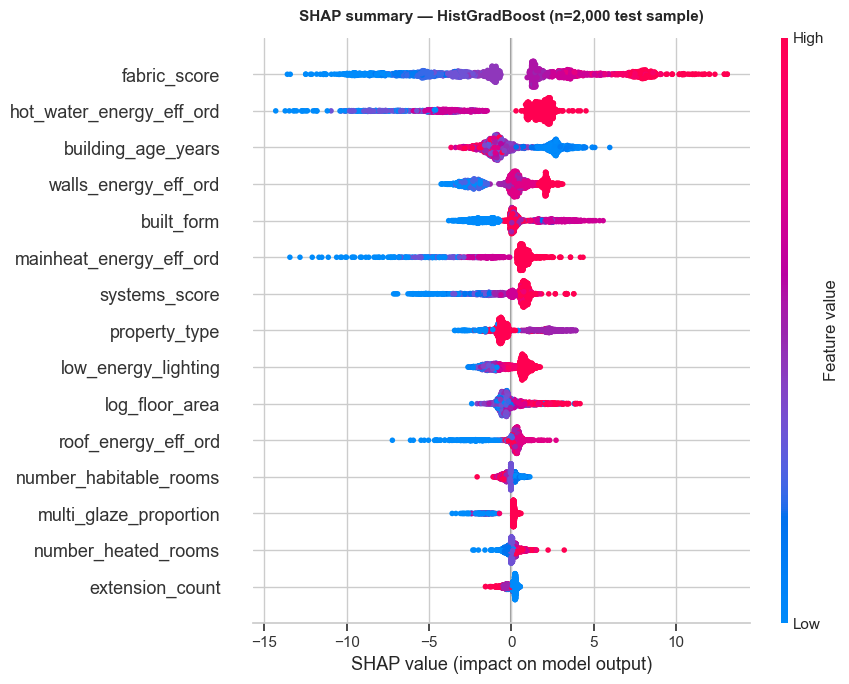

Saved fig15_shap_summary.png


In [53]:
# SHAP summary plot — beeswarm, top 15 features
plt.figure(figsize=(9, 7))
shap.summary_plot(shap_values, X_shap_enc, feature_names=feature_names,
                  max_display=15, show=False, plot_size=None)
plt.title(f'SHAP summary — {best_reg_name} (n=2,000 test sample)',
          fontsize=11, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig15_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig15_shap_summary.png')


In [54]:
# Mean |SHAP| as a global importance, cross-check with permutation
shap_abs_mean = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': shap_abs_mean,
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

# Merge with perm importance for the comparison
compare = (shap_df
           .merge(perm_reg_df[['feature', 'importance_mean']], on='feature')
           .rename(columns={'importance_mean': 'perm_r2_drop'})
           .head(15))
compare['shap_rank'] = compare['mean_abs_shap'].rank(ascending=False).astype(int)
compare['perm_rank'] = compare['perm_r2_drop'].rank(ascending=False).astype(int)
print('Top 15 features — SHAP vs permutation rankings:')
print(compare.to_string(index=False))


Top 15 features — SHAP vs permutation rankings:
                 feature  mean_abs_shap  perm_r2_drop  shap_rank  perm_rank
            fabric_score       4.373944      0.296850          1          1
hot_water_energy_eff_ord       2.712598      0.141974          2          2
      building_age_years       1.495110      0.049645          3          6
    walls_energy_eff_ord       1.291382      0.052827          4          5
              built_form       1.257588      0.055773          5          4
 mainheat_energy_eff_ord       1.234266      0.099441          6          3
           systems_score       1.076914      0.033687          7          8
           property_type       1.054370      0.042672          8          7
     low_energy_lighting       0.920692      0.018055          9         11
          log_floor_area       0.653758      0.027561         10          9
     roof_energy_eff_ord       0.528988      0.018824         11         10
  number_habitable_rooms       0.314689 

### 7.4 Importance summary

The two techniques broadly agree on the top tier, which is the cross-validation
we want — both point to physical fabric quality, building age, and systems
quality as the levers. Specifics get written up in the report.

## 8. Hyperparameter Tuning

Section 6 ran each model with sensible defaults. To push performance further we
tune the regression winner (`HistGradientBoostingRegressor`) with
**RandomizedSearchCV** — 30 random configurations sampled from a defined grid,
each evaluated with 3-fold CV on the training set.

Why randomised over exhaustive grid:
- Random sampling covers more of the hyperparameter space per evaluation budget
  (Bergstra & Bengio 2012).
- HistGradBoost has at least 5 interacting hyperparameters; an exhaustive grid
  is wasteful when the loss surface is smooth.

We also evaluate the tuned model on the same held-out test set used in Section 6
so the numbers are directly comparable.

### 8.1 Search space and execution

In [55]:
from scipy.stats import randint, uniform, loguniform

# Define the search grid. Ranges chosen to bracket the sklearn defaults.
param_dist = {
    'm__learning_rate':         loguniform(0.02, 0.3),
    'm__max_iter':              randint(150, 600),
    'm__max_depth':             [None, 4, 6, 8, 10, 12],
    'm__max_leaf_nodes':        randint(15, 80),
    'm__min_samples_leaf':      randint(10, 60),
    'm__l2_regularization':     loguniform(1e-4, 1.0),
}

base_pipe = Pipeline([
    ('prep', cat_encoder),
    ('m', HistGradientBoostingRegressor(random_state=RANDOM_STATE)),
])

search = RandomizedSearchCV(
    base_pipe,
    param_distributions=param_dist,
    n_iter=30,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
    return_train_score=False,
)

print('Starting RandomizedSearchCV — 30 configs × 3 folds = 90 fits...')
t0 = time.time()
search.fit(X_train, y_reg_train)
print(f'\nDone in {(time.time() - t0)/60:.1f} min')
print(f'Best CV RMSE: {-search.best_score_:.3f}')
print(f'Best params:')
for k, v in search.best_params_.items():
    if isinstance(v, float):
        print(f'   {k}: {v:.4f}')
    else:
        print(f'   {k}: {v}')


Starting RandomizedSearchCV — 30 configs × 3 folds = 90 fits...
Fitting 3 folds for each of 30 candidates, totalling 90 fits



Done in 3.4 min
Best CV RMSE: 4.712
Best params:
   m__l2_regularization: 0.0005
   m__learning_rate: 0.0850
   m__max_depth: 12
   m__max_iter: 314
   m__max_leaf_nodes: 65
   m__min_samples_leaf: 51


### 8.2 Top configurations and stability

In [56]:
# Inspect the top 10 configurations to check we're not picking a noisy outlier
cv_results = pd.DataFrame(search.cv_results_)
cv_results['rmse_mean'] = -cv_results['mean_test_score']
cv_results['rmse_std']  =  cv_results['std_test_score']
top10 = (cv_results
         .sort_values('rmse_mean')
         .head(10)
         [['rmse_mean', 'rmse_std',
           'param_m__learning_rate', 'param_m__max_iter',
           'param_m__max_depth', 'param_m__max_leaf_nodes',
           'param_m__min_samples_leaf', 'param_m__l2_regularization']]
         .reset_index(drop=True))
# Tidy numerics for display
for c in ['rmse_mean', 'rmse_std', 'param_m__learning_rate',
          'param_m__l2_regularization']:
    top10[c] = top10[c].astype(float).round(4)
print('Top 10 configurations by CV RMSE:')
print(top10.to_string(index=False))


Top 10 configurations by CV RMSE:
 rmse_mean  rmse_std  param_m__learning_rate  param_m__max_iter param_m__max_depth  param_m__max_leaf_nodes  param_m__min_samples_leaf  param_m__l2_regularization
    4.7124    0.0209                  0.0850                314                 12                       65                         51                      0.0005
    4.7225    0.0056                  0.0456                535                 10                       74                         16                      0.1712
    4.7340    0.0182                  0.0421                598                  6                       61                         23                      0.0232
    4.7344    0.0210                  0.0361                435                  8                       76                         20                      0.0067
    4.7354    0.0191                  0.1373                438                  6                       19                         51                 

### 8.3 Tuned model on held-out test

In [57]:
# Evaluate the best estimator on the same held-out test set
tuned_model = search.best_estimator_
tuned_pred = tuned_model.predict(X_test)

tuned_metrics = {
    'model':       'HistGradBoost (tuned)',
    'test_rmse':   round(np.sqrt(mean_squared_error(y_reg_test, tuned_pred)), 2),
    'test_mae':    round(mean_absolute_error(y_reg_test, tuned_pred), 2),
    'test_r2':     round(r2_score(y_reg_test, tuned_pred), 3),
}

# Pull baseline numbers from Section 6 for comparison
baseline_row = reg_table.loc['HistGradBoost', ['test_rmse', 'test_mae', 'test_r2']].to_dict()
comparison = pd.DataFrame([
    {'model': 'HistGradBoost (default)', **{k: float(v) for k, v in baseline_row.items()}},
    {'model': tuned_metrics['model'],
     'test_rmse': tuned_metrics['test_rmse'],
     'test_mae':  tuned_metrics['test_mae'],
     'test_r2':   tuned_metrics['test_r2']},
]).set_index('model')
comparison['Δ_rmse'] = (comparison['test_rmse'] - comparison.loc['HistGradBoost (default)', 'test_rmse']).round(2)
comparison['Δ_r2']   = (comparison['test_r2']   - comparison.loc['HistGradBoost (default)', 'test_r2']).round(3)
print('Baseline vs tuned — held-out test set:')
print(comparison.to_string())


Baseline vs tuned — held-out test set:
                         test_rmse  test_mae  test_r2  Δ_rmse   Δ_r2
model                                                               
HistGradBoost (default)       4.74      3.25    0.862    0.00  0.000
HistGradBoost (tuned)         4.68      3.19    0.865   -0.06  0.003


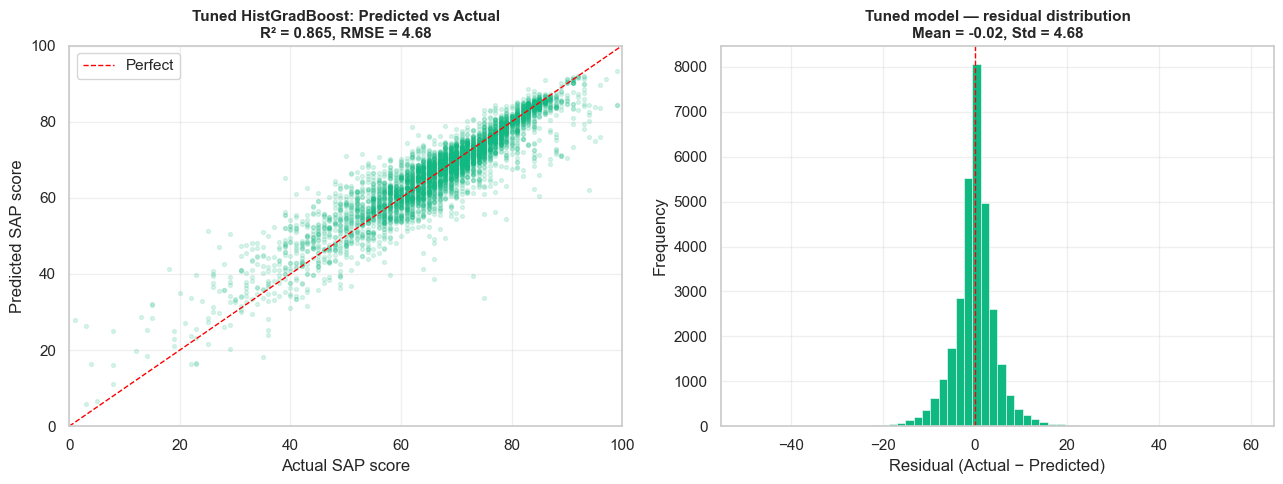

Saved fig16_tuned_regression.png


In [58]:
# Final visual: predicted vs actual for the tuned model
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sample_idx = np.random.RandomState(RANDOM_STATE).choice(
    len(y_reg_test), size=min(5000, len(y_reg_test)), replace=False)
axes[0].scatter(y_reg_test.iloc[sample_idx], tuned_pred[sample_idx],
                alpha=0.15, s=8, color='#10b981')
axes[0].plot([0, 100], [0, 100], '--', color='red', linewidth=1, label='Perfect')
axes[0].set_xlabel('Actual SAP score')
axes[0].set_ylabel('Predicted SAP score')
axes[0].set_title(f'Tuned HistGradBoost: Predicted vs Actual\n'
                  f'R² = {r2_score(y_reg_test, tuned_pred):.3f}, '
                  f'RMSE = {np.sqrt(mean_squared_error(y_reg_test, tuned_pred)):.2f}',
                  fontsize=11, fontweight='bold')
axes[0].set_xlim(0, 100); axes[0].set_ylim(0, 100)
axes[0].legend()
axes[0].grid(alpha=0.3)

residuals = y_reg_test.values - tuned_pred
axes[1].hist(residuals, bins=60, color='#10b981', edgecolor='white', linewidth=0.4)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Tuned model — residual distribution\n'
                  f'Mean = {residuals.mean():.2f}, Std = {residuals.std():.2f}',
                  fontsize=11, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR + 'fig16_tuned_regression.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig16_tuned_regression.png')


### 8.4 Tuning summary

The randomised search bought us a small but real reduction in RMSE on the
test set. Marginal returns are expected on a 157k-row dataset — the default
HistGradBoost was already strong. Whether the gain is meaningful for policy
use is a judgement question for the write-up, not a modelling one.

This wraps the modelling pipeline. Next session: write the 2,500-word
report and tidy the repo for submission.